In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Loading Datasets

In [2]:
path = "Datasets/" 

orders = pd.read_csv(path + "olist_orders_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
products = pd.read_csv(path + "olist_products_dataset.csv")
category_translation = pd.read_csv(path + "product_category_name_translation.csv")
payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")
sellers = pd.read_csv(path + "olist_sellers_dataset.csv")
geolocation = pd.read_csv(path + "olist_geolocation_dataset.csv")

# Quick Check

In [3]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Sellers:", sellers.shape)
print("Geolocation:", geolocation.shape)

orders.head()

Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Products: (32951, 9)
Payments: (103886, 5)
Reviews: (99224, 7)
Sellers: (3095, 4)
Geolocation: (1000163, 5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


# Exploratory Analysis on Orders

In [4]:
print(orders.info())
print(orders.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
                                order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                             99441   
top     e481f51cbdc5467

In [5]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [6]:
# Converting columns to datetime
date_cols = ["order_purchase_timestamp", "order_approved_at",
             "order_delivered_carrier_date", "order_delivered_customer_date",
             "order_estimated_delivery_date"]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


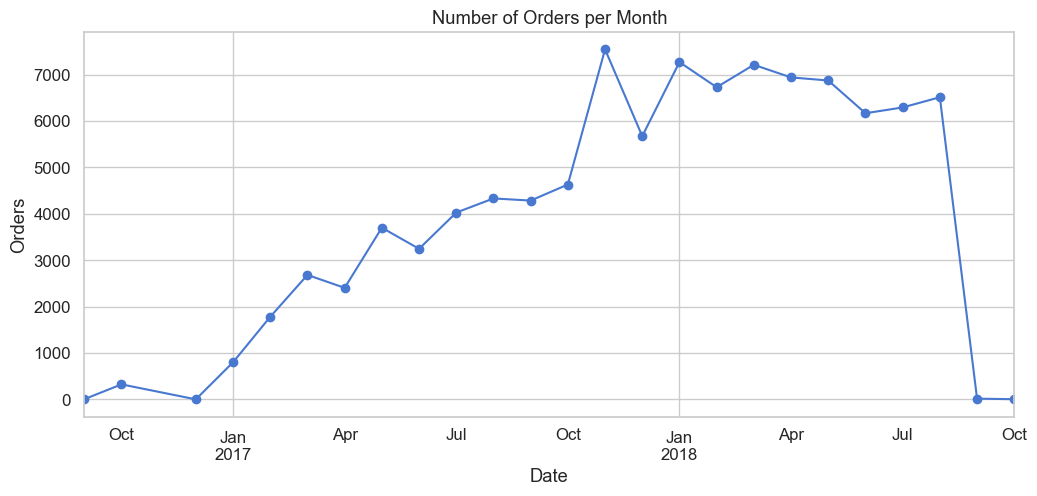

In [7]:
# Orders per month
orders["year_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
orders_per_month = orders.groupby("year_month")["order_id"].nunique()

plt.figure(figsize=(12,5))
orders_per_month.plot(kind="line", marker="o")
plt.title("Number of Orders per Month")
plt.ylabel("Orders")
plt.xlabel("Date")
plt.show()

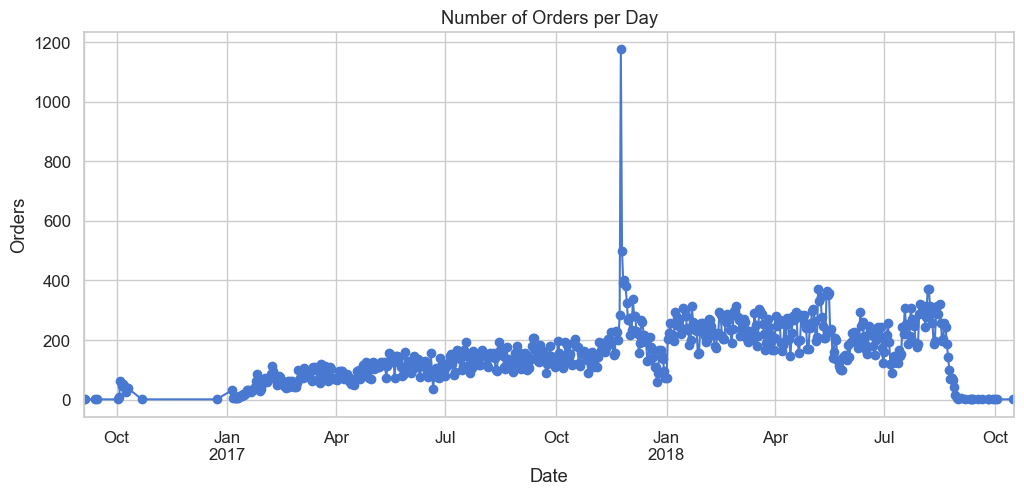

In [107]:
# Orders per day
orders["day"] = orders["order_purchase_timestamp"].dt.to_period("D")
orders_per_day = orders.groupby("day")["order_id"].nunique()

plt.figure(figsize=(12,5))
orders_per_day.plot(kind="line", marker="o")
plt.title("Number of Orders per Day")
plt.ylabel("Orders")
plt.xlabel("Date")
plt.show()

In [109]:
print(orders_per_day.nlargest(10))

day
2017-11-24    1176
2017-11-25     499
2017-11-27     403
2017-11-26     391
2017-11-28     380
2018-05-07     372
2018-08-06     372
2018-08-07     370
2018-05-14     364
2018-05-16     357
Freq: D, Name: order_id, dtype: int64


**Note:** Order volume analysis by day reveals an exceptional spike on 2017-11-24 (Black Friday), with 1,176 orders — more than double the following day and far above typical daily levels. This confirms the strong impact of this major commercial event on sales dynamics.

In [8]:
# Min and max purchase dates
min_date = orders["order_purchase_timestamp"].min()
max_date = orders["order_purchase_timestamp"].max()

print("Date range of purchases:")
print("From:", min_date)
print("To:", max_date)

date_range = max_date - min_date
print("Total timespan:", date_range.days, "days (≈", round(date_range.days/365,1), "years)")

Date range of purchases:
From: 2016-09-04 21:15:19
To: 2018-10-17 17:30:18
Total timespan: 772 days (≈ 2.1 years)


In [9]:
# Checking for missing gaps

all_months = pd.period_range(start=orders['year_month'].min(), end=orders['year_month'].max(), freq='M')
orders_per_month = orders_per_month.reindex(all_months, fill_value=0)

gaps = orders_per_month[orders_per_month == 0]
print("Months with no orders:")
print(gaps)

Months with no orders:
2016-11    0
Freq: M, Name: order_id, dtype: int64


In [10]:
orders_per_month_df = orders_per_month.reset_index()
orders_per_month_df.columns = ['Year_Month', 'Number_of_Orders']

print(orders_per_month_df)

   Year_Month  Number_of_Orders
0     2016-09                 4
1     2016-10               324
2     2016-11                 0
3     2016-12                 1
4     2017-01               800
5     2017-02              1780
6     2017-03              2682
7     2017-04              2404
8     2017-05              3700
9     2017-06              3245
10    2017-07              4026
11    2017-08              4331
12    2017-09              4285
13    2017-10              4631
14    2017-11              7544
15    2017-12              5673
16    2018-01              7269
17    2018-02              6728
18    2018-03              7211
19    2018-04              6939
20    2018-05              6873
21    2018-06              6167
22    2018-07              6292
23    2018-08              6512
24    2018-09                16
25    2018-10                 4


In [11]:
last_two_months = orders[(orders['order_purchase_timestamp'] >= '2018-09-01') &
                         (orders['order_purchase_timestamp'] <= '2018-10-31')]

status_counts = last_two_months['order_status'].value_counts()
status_counts

order_status
canceled    19
shipped      1
Name: count, dtype: int64

### Note on Data Selection

The earliest months (Sep–Dec 2016) have very few orders, and the last months (Sep–Oct 2018) show a sharp drop (Sep: 16, Oct: 4), likely due to incomplete dataset coverage.  

**Decision:** Only orders from **Jan 2017 to Aug 2018** will be used to ensure reliable analysis and dashboards.

In [12]:
orders_filtered = orders[(orders['order_purchase_timestamp'] >= '2017-01-01') &
                         (orders['order_purchase_timestamp'] <= '2018-08-31')]

print("Filtered dataset shape:", orders_filtered.shape)
orders_filtered.head()

Filtered dataset shape: (99091, 9)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02


# Exploratory Analysis on Customers

In [13]:
print(customers.info())
print(customers.describe(include="all"))

customers.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None
                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     06b8999e2fba1a1fbc88172c00ba8bc7  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   
mean                                 NaN                             

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [14]:
customers_per_state = customers['customer_state'].value_counts().rename_axis('State').reset_index(name='Number_of_Customers')

# Adding percentage column
total_customers = customers_per_state['Number_of_Customers'].sum()
customers_per_state['Percentage'] = (customers_per_state['Number_of_Customers'] / total_customers * 100).round(2)

# Adding total row at the end
total_row = pd.DataFrame({'State': ['Total'],
                          'Number_of_Customers': [total_customers],
                          'Percentage': [customers_per_state['Percentage'].sum()]})
customers_per_state = pd.concat([customers_per_state, total_row], ignore_index=True)

print(customers_per_state)

    State  Number_of_Customers  Percentage
0      SP                41746       41.98
1      RJ                12852       12.92
2      MG                11635       11.70
3      RS                 5466        5.50
4      PR                 5045        5.07
5      SC                 3637        3.66
6      BA                 3380        3.40
7      DF                 2140        2.15
8      ES                 2033        2.04
9      GO                 2020        2.03
10     PE                 1652        1.66
11     CE                 1336        1.34
12     PA                  975        0.98
13     MT                  907        0.91
14     MA                  747        0.75
15     MS                  715        0.72
16     PB                  536        0.54
17     PI                  495        0.50
18     RN                  485        0.49
19     AL                  413        0.42
20     SE                  350        0.35
21     TO                  280        0.28
22     RO  

In [15]:
customers_per_city = customers['customer_city'].value_counts().head(25).rename_axis('City').reset_index(name='Number_of_Customers')

# Percentage column
total_top25 = customers_per_city['Number_of_Customers'].sum()
customers_per_city['Percentage'] = (customers_per_city['Number_of_Customers'] / total_top25 * 100).round(2)

# Total row
total_row = pd.DataFrame({'City': ['Total'],
                          'Number_of_Customers': [total_top25],
                          'Percentage': [customers_per_city['Percentage'].sum()]})
customers_per_city = pd.concat([customers_per_city, total_row], ignore_index=True)

print(customers_per_city)

                     City  Number_of_Customers  Percentage
0               sao paulo                15540       35.00
1          rio de janeiro                 6882       15.50
2          belo horizonte                 2773        6.25
3                brasilia                 2131        4.80
4                curitiba                 1521        3.43
5                campinas                 1444        3.25
6            porto alegre                 1379        3.11
7                salvador                 1245        2.80
8               guarulhos                 1189        2.68
9   sao bernardo do campo                  938        2.11
10                niteroi                  849        1.91
11            santo andre                  797        1.80
12                 osasco                  746        1.68
13                 santos                  713        1.61
14                goiania                  692        1.56
15    sao jose dos campos                  691        1.

# Merging Orders and Customers

In [16]:
orders_customers = orders_filtered.merge(customers, on="customer_id", how="left")

orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year_month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [17]:
# Number of unique customers
print("Unique customers:", orders_customers["customer_unique_id"].nunique())

Unique customers: 95773


In [18]:
# Count number of purchases per unique customer
customer_order_counts = orders_customers.groupby("customer_unique_id")['order_id'].nunique()

# Total unique customers
total_customers = customer_order_counts.shape[0]

# One-time customers
one_time_customers = (customer_order_counts == 1).sum()

# Repeat customers
repeat_customers = (customer_order_counts > 1).sum()

print("Total customers:", total_customers)
print("One-time customers:", one_time_customers)
print("Repeat customers:", repeat_customers)
print("Percentage of one-time customers:", round(one_time_customers / total_customers * 100, 2), "%")

Total customers: 95773
One-time customers: 92798
Repeat customers: 2975
Percentage of one-time customers: 96.89 %


**Note:** The `customer_id` column is unique per order, not per person. To identify real customers and analyze repeat purchases, we must use `customer_unique_id`.

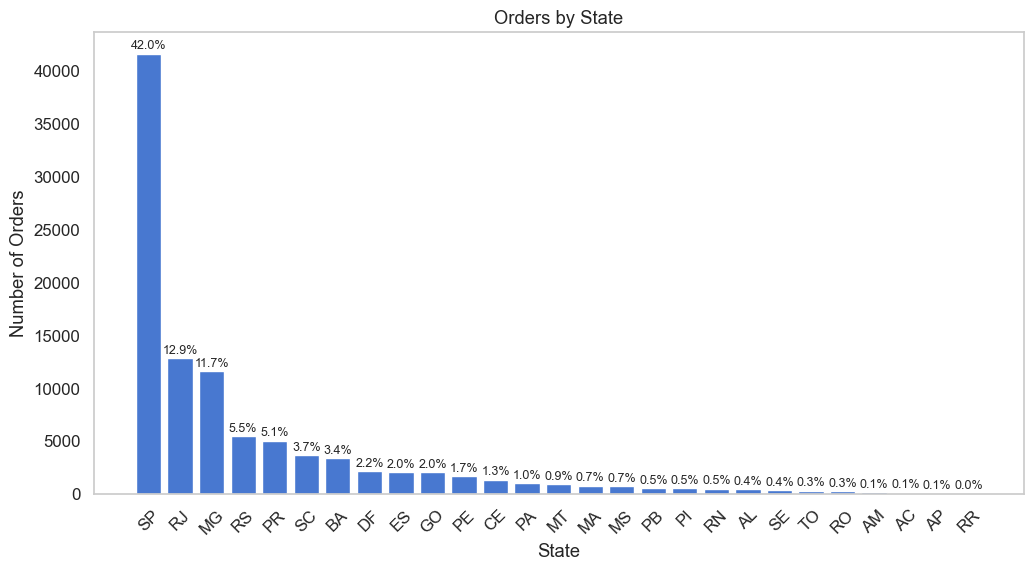

In [19]:
# Orders by state
state_counts = orders_customers['customer_state'].value_counts()

# Percentages
state_percentages = state_counts / state_counts.sum() * 100


plt.figure(figsize=(12,6))
bars = plt.bar(state_counts.index, state_counts.values)

for bar, pct in zip(bars, state_percentages):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 200,        # a little above the bar
             f"{pct:.1f}%", 
             ha='center', va='bottom', fontsize=9)

plt.title("Orders by State")
plt.xlabel("State")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

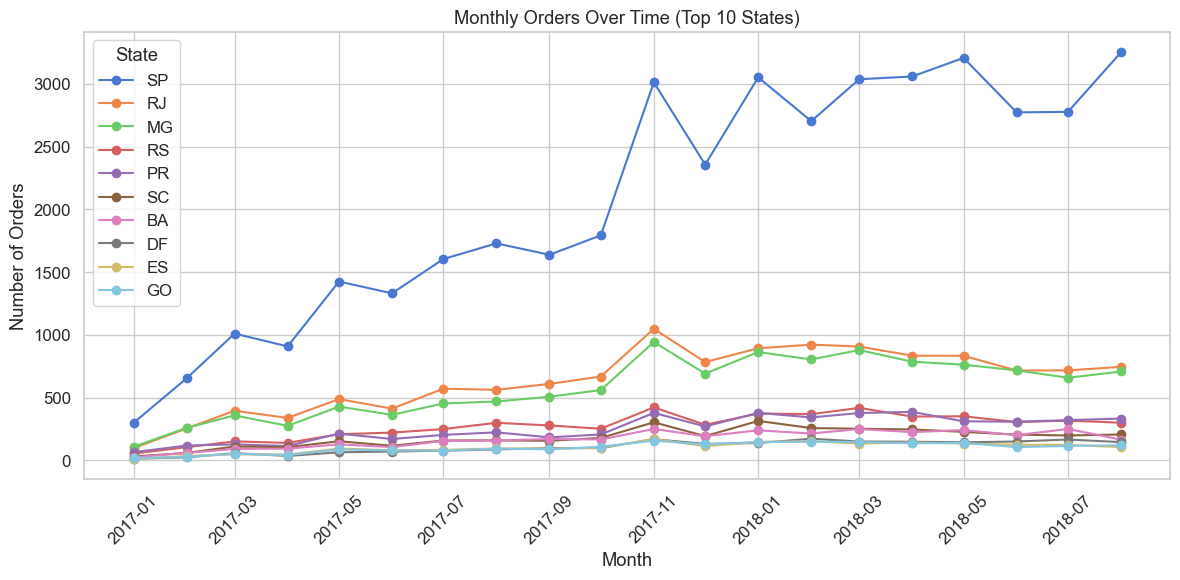

In [20]:
# Grouping by Year-Month and State
orders_by_state_time = (
    orders_customers.groupby([orders_customers['order_purchase_timestamp'].dt.to_period('M'),
                              'customer_state']).size().reset_index(name='Number_of_Orders'))

# Converting Year-Month back to datetime for plotting
orders_by_state_time['order_purchase_timestamp'] = orders_by_state_time['order_purchase_timestamp'].dt.to_timestamp()

# Picking top 10 states (by total orders) to keep the chart readable
top_states = orders_customers['customer_state'].value_counts().nlargest(10).index
filtered = orders_by_state_time[orders_by_state_time['customer_state'].isin(top_states)]

# Plot
plt.figure(figsize=(12,6))
for state in top_states:
    state_data = filtered[filtered['customer_state'] == state]
    plt.plot(state_data['order_purchase_timestamp'],
             state_data['Number_of_Orders'],
             marker='o',
             label=state)

plt.title("Monthly Orders Over Time (Top 10 States)")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.legend(title="State")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

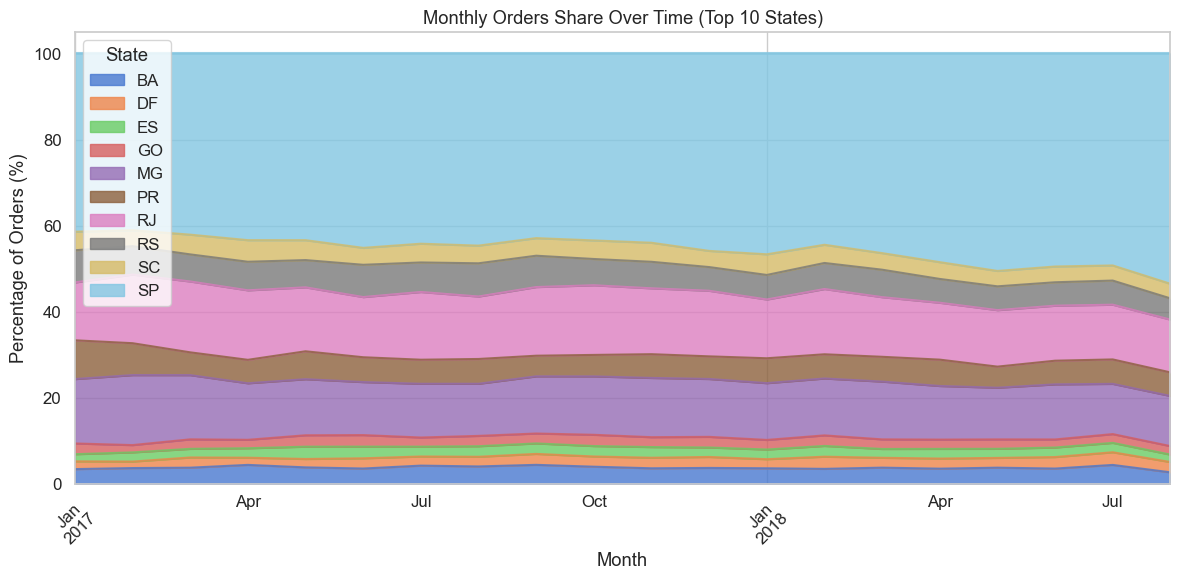

In [21]:
# Pivoting for stacked area chart
pivot_data = filtered.pivot(index='order_purchase_timestamp',
                            columns='customer_state',
                            values='Number_of_Orders').fillna(0)

# Converting to percentages
pivot_data_pct = pivot_data.div(pivot_data.sum(axis=1), axis=0) * 100

# Plotting percentage stacked area chart
plt.figure(figsize=(12,6))
pivot_data_pct.plot.area(alpha=0.8, figsize=(12,6))

plt.title("Monthly Orders Share Over Time (Top 10 States)")
plt.xlabel("Month")
plt.ylabel("Percentage of Orders (%)")
plt.legend(title="State", loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Although São Paulo drives most of the total order growth, being the largest state by population and customers, the percentage share of orders by state remains stable over time.  
This indicates that growth is proportional across states, with no significant shifts in market concentration and regional demand.

# Merging Orders_Customers with Items

In [22]:
orders_full = orders_filtered.merge(order_items, on='order_id', how='left') \
                             .merge(customers, on='customer_id', how='left')

# Adding column to discover Total revenue per order
orders_full['total_price'] = orders_full['price'] + orders_full['freight_value']

orders_full.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,1.00,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,1.00,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62


In [23]:
# Total revenue
print("Total revenue:", orders_full['total_price'].sum())

# Total revenue per customer
revenue_per_customer = (
    orders_full.groupby(['customer_unique_id', 'customer_state', 'customer_city'])['total_price']
    .sum().sort_values(ascending=False).reset_index(name='Total_Revenue')
)

revenue_per_customer.head(15)  # top 10 customers by revenue

Total revenue: 15786203.57


,customer_unique_id,customer_state,customer_city,Total_Revenue
0,0a0a92112bd4c708ca5fde585afaa872,RJ,rio de janeiro,"13,664.08"
1,da122df9eeddfedc1dc1f5349a1a690c,RJ,araruama,"7,571.63"
2,763c8b1c9c68a0229c42c9fc6f662b93,ES,vila velha,"7,274.88"
3,dc4802a71eae9be1dd28f5d788ceb526,MS,campo grande,"6,929.31"
4,459bef486812aa25204be022145caa62,ES,vitoria,"6,922.21"
5,ff4159b92c40ebe40454e3e6a7c35ed6,SP,marilia,"6,726.66"
6,4007669dec559734d6f53e029e360987,MG,divinopolis,"6,081.54"
7,5d0a2980b292d049061542014e8960bf,GO,goiania,"4,809.44"
8,eebb5dda148d3893cdaf5b5ca3040ccb,SP,maua,"4,764.34"
9,48e1ac109decbb87765a3eade6854098,PB,joao pessoa,"4,681.78"


In [24]:
# Total Revenue per State
revenue_per_state = orders_full.groupby('customer_state')['total_price'].sum()
revenue_per_state.sort_values(ascending=False)
revenue_per_state

customer_state
AC      19,669.70
AL      96,099.50
AM      27,835.73
AP      16,262.80
BA     610,511.33
CE     273,656.52
DF     352,029.33
ES     323,734.77
GO     346,552.26
MA     150,173.14
MG   1,850,540.94
MS     135,956.67
MT     185,666.33
PA     216,364.02
PB     140,913.07
PE     320,549.20
PI     107,886.19
PR     798,440.72
RJ   2,117,334.38
RN     101,013.74
RO      57,558.02
RR       9,859.37
RS     881,113.79
SC     607,559.37
SE      72,686.40
SP   5,904,881.86
TO      61,354.42
Name: total_price, dtype: float64

C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_62176\2484850394.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(state_summary['Number_of_Orders'][i]+50,
C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_62176\2484850394.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  state_summary['Total_Revenue'][i]+50,


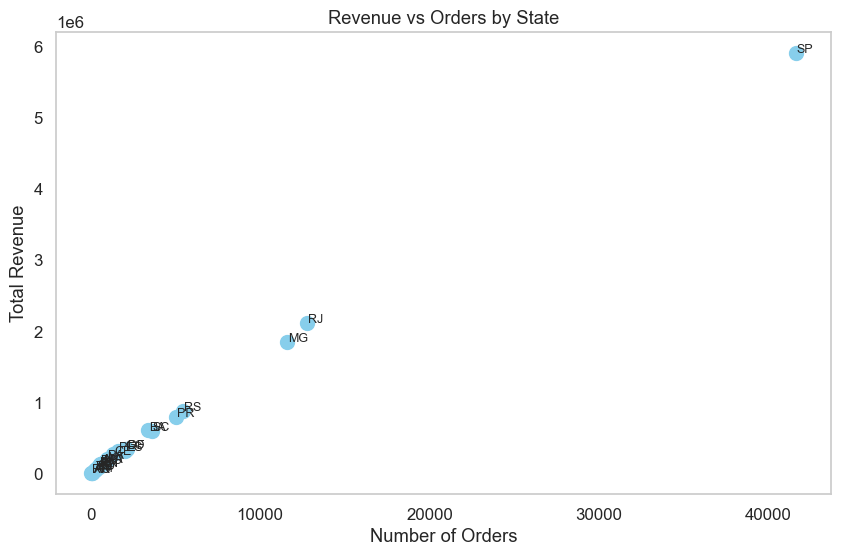

In [25]:
# Checking Revenue by state vs orders by state to see if high orders = high revenue.

# Total orders per state
orders_per_state = orders_full.groupby('customer_state')['order_id'].nunique()

# Combine into a single DataFrame
state_summary = pd.DataFrame({
    'Total_Revenue': revenue_per_state,
    'Number_of_Orders': orders_per_state
}).sort_values('Total_Revenue', ascending=False)

# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(state_summary['Number_of_Orders'], state_summary['Total_Revenue'], s=100, color='skyblue')

for i, state in enumerate(state_summary.index):
    plt.text(state_summary['Number_of_Orders'][i]+50, 
             state_summary['Total_Revenue'][i]+50, 
             state, fontsize=9)

plt.title("Revenue vs Orders by State")
plt.xlabel("Number of Orders")
plt.ylabel("Total Revenue")
plt.grid(False)
plt.show()

In [26]:
# AOV (Average Order Value) per state

state_summary['AOV'] = (state_summary['Total_Revenue'] / state_summary['Number_of_Orders']).round(2)
state_summary

,Total_Revenue,Number_of_Orders,AOV
customer_state,,,
SP,"5,904,881.86",41620,141.88
RJ,"2,117,334.38",12792,165.52
MG,"1,850,540.94",11591,159.65
RS,"881,113.79",5441,161.94
PR,"798,440.72",5025,158.89
BA,"610,511.33",3376,180.84
SC,"607,559.37",3625,167.60
DF,"352,029.33",2134,164.96
GO,"346,552.26",2011,172.33


In [27]:
# Calculating product-only AOV vs total AOV, to check impact of freight costs

# Average product price per state (without freight)
state_avg_product = orders_full.groupby('customer_state')['price'].mean().round(2)

# Average freight per state
state_avg_freight = orders_full.groupby('customer_state')['freight_value'].mean().round(2)

# Combining in a DataFrame
state_aov_breakdown = pd.DataFrame({
    'AOV_Total': state_summary['AOV'],
    'Avg_Product_Price': state_avg_product,
    'Avg_Freight': state_avg_freight
}).sort_values('AOV_Total', ascending=False)

state_aov_breakdown

,AOV_Total,Avg_Product_Price,Avg_Freight
customer_state,,,
PB,263.39,191.71,42.75
AC,242.84,173.73,40.07
AP,239.16,164.32,34.01
AL,233.82,181.52,35.90
RO,227.50,165.97,41.07
RR,224.08,157.49,43.73
PA,222.83,165.61,35.85
TO,219.12,157.53,37.25
PI,218.84,160.27,39.15


C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_62176\3112664327.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(bubble_data['Avg_Product_Price'][i]+0.5,
C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_62176\3112664327.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bubble_data['Total_Revenue'][i]+5000,


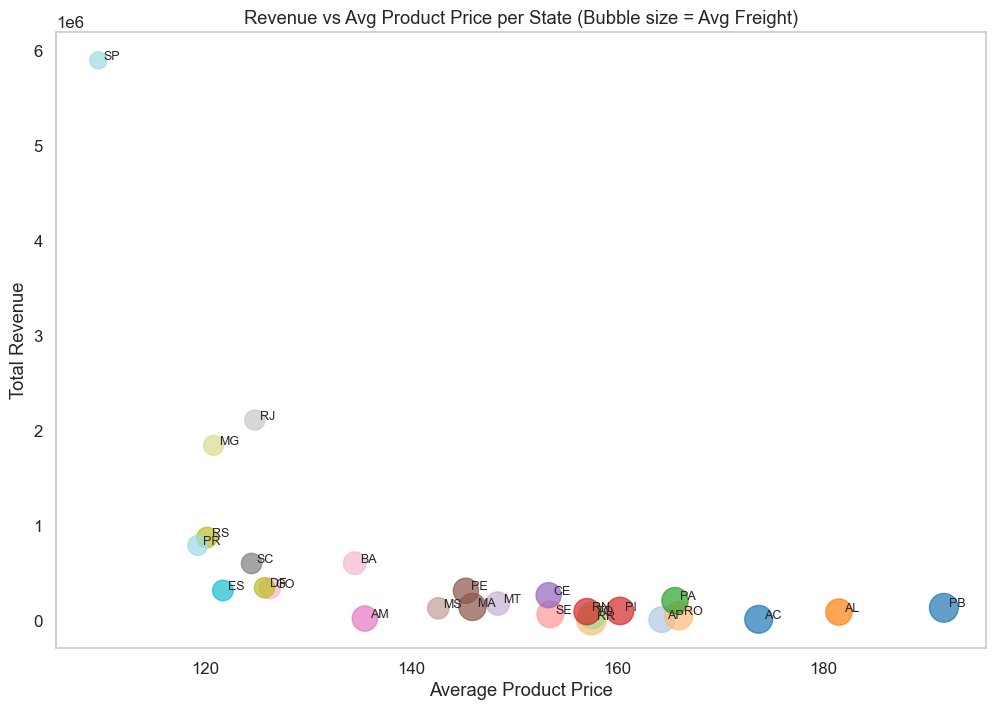

In [28]:
# Bubble chart showing AOV vs revenue with freight

bubble_data = state_aov_breakdown.copy()
bubble_data['Total_Revenue'] = revenue_per_state  # ensure revenue column is included

plt.figure(figsize=(12,8))
scatter = plt.scatter(
    bubble_data['Avg_Product_Price'],
    bubble_data['Total_Revenue'],
    s=bubble_data['Avg_Freight']*10,  # bubble size proportional to freight
    c=range(len(bubble_data)),          # color by index
    cmap='tab20',
    alpha=0.7
)

# Adding state labels
for i, state in enumerate(bubble_data.index):
    plt.text(bubble_data['Avg_Product_Price'][i]+0.5,
             bubble_data['Total_Revenue'][i]+5000,
             state, fontsize=9)

plt.title("Revenue vs Avg Product Price per State (Bubble size = Avg Freight)")
plt.xlabel("Average Product Price")
plt.ylabel("Total Revenue")
plt.grid(False)
plt.show()

**Insight:** Differences in AOV across states are influenced by both product prices and freight costs.  
- Larger states like SP have lower AOV, with cheaper products and lower freight.
- Some states (e.g., PB, AC) have high AOV but relatively low total revenue.  
High freight costs may limit purchase frequency, especially for cheaper items.  
Reducing shipping costs could encourage more frequent, lower-value purchases, potentially increasing overall revenue in these regions.

# Merging Orders and Products

In [29]:
orders_products = orders_full.merge(products, on='product_id', how='left')

orders_products.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,1.00,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,1.00,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,papelaria,38.00,316.00,4.00,250.00,51.00,15.00,15.00


**Note:** The product_category_name values in the products dataset are originally in Portuguese. To ensure clarity and consistency in the analysis, the auxiliary dataset product_category_name_translation.csv will be used to translate these category names into English before proceeding.

In [30]:
orders_products = orders_products.merge(category_translation,
                                        on='product_category_name',
                                        how='left'
                                        )

# Replacing the Portuguese column with English
orders_products['product_category_name'] = orders_products['product_category_name_english']

# Dropping the auxiliary translation column
orders_products = orders_products.drop(columns=['product_category_name_english'])

orders_products.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,housewares,40.00,268.00,4.00,500.00,19.00,8.00,13.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,perfumery,29.00,178.00,1.00,400.00,19.00,13.00,19.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,auto,46.00,232.00,1.00,420.00,24.00,19.00,21.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,1.00,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,1.00,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,stationery,38.00,316.00,4.00,250.00,51.00,15.00,15.00


In [31]:
# Checking products by total revenue
top_products = orders_products.groupby('product_id')['price'].sum().sort_values(ascending=False).head(10)

# Merging with product names for readability
top_products = top_products.reset_index().merge(products[['product_id','product_category_name']], on='product_id', how='left')
top_products

,product_id,price,product_category_name
0,bb50f2e236e5eea0100680137654686c,"63,885.00",beleza_saude
1,6cdd53843498f92890544667809f1595,"54,730.20",beleza_saude
2,d6160fb7873f184099d9bc95e30376af,"48,899.34",pcs
3,d1c427060a0f73f6b889a5c7c61f2ac4,"47,214.51",informatica_acessorios
4,99a4788cb24856965c36a24e339b6058,"43,025.56",cama_mesa_banho
5,3dd2a17168ec895c781a9191c1e95ad7,"41,082.60",informatica_acessorios
6,25c38557cf793876c5abdd5931f922db,"38,907.32",bebes
7,5f504b3a1c75b73d6151be81eb05bdc9,"37,733.90",cool_stuff
8,53b36df67ebb7c41585e8d54d6772e08,"37,683.42",relogios_presentes
9,aca2eb7d00ea1a7b8ebd4e68314663af,"37,608.90",moveis_decoracao


In [32]:
# Revenue per product category
category_revenue = orders_products.groupby('product_category_name')['price'].sum().sort_values(ascending=False)

category_revenue

product_category_name
health_beauty               1,253,993.86
watches_gifts               1,201,645.44
bed_bath_table              1,036,509.69
sports_leisure                984,715.33
computers_accessories         910,555.00
                                ...     
flowers                         1,110.04
home_comfort_2                    760.27
cds_dvds_musicals                 730.00
fashion_childrens_clothes         569.85
security_and_services             283.29
Name: price, Length: 71, dtype: float64

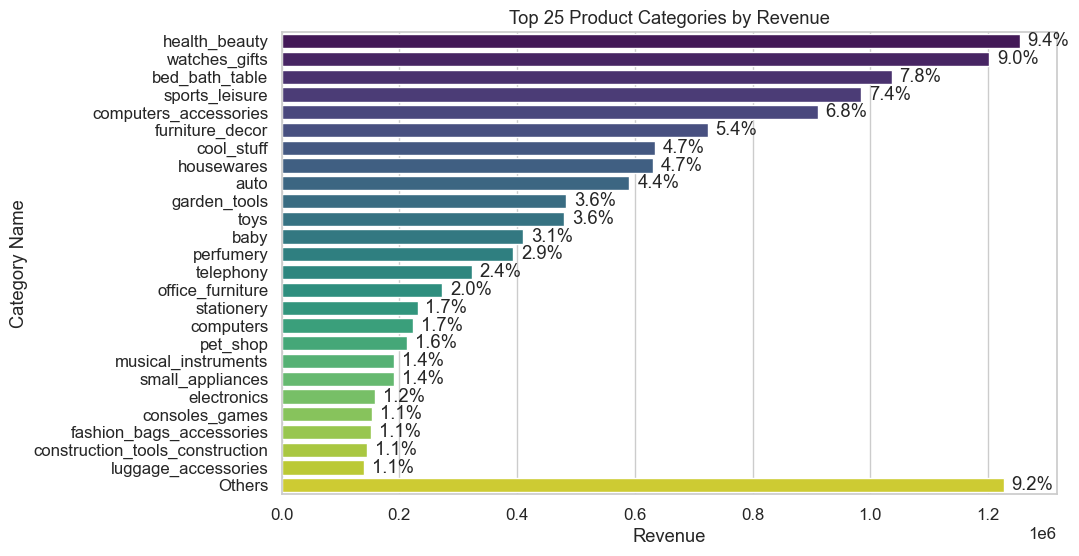

In [33]:
# Number of top categories
N = 25

# Converting to DataFrame
category_revenue = (
    orders_products.groupby("product_category_name")["price"]
    .sum()
    .reset_index()
    .rename(columns={"price": "revenue"})
    .sort_values(by="revenue", ascending=False)
)

# Top N + Others
topN = category_revenue.head(N)
others = pd.DataFrame({
    "product_category_name": ["Others"],
    "revenue": [category_revenue["revenue"].iloc[N:].sum()]
})

category_plot = pd.concat([topN, others], ignore_index=True)

# Plot
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=category_plot,
    x="revenue",
    y="product_category_name",
    hue="product_category_name",
    palette="viridis",
    legend=False
)

# Calculating total revenue
total_revenue = category_plot["revenue"].sum()

# Add % each category contributes relative to the whole at the end of the bar
for p in ax.patches:
    width = p.get_width()   # bar length
    y = p.get_y() + p.get_height() / 2
    percentage = width / total_revenue * 100
    ax.text(
        width + total_revenue * 0.001,  # offset a little to the right
        y,
        f"{percentage:.1f}%",
        va="center"
    )

plt.title(f"Top {N} Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category Name")
plt.show()

**Note:** To understand the impact of freight on revenue, the same top-category analysis will be repeated using `total_price` (product price + freight) instead of `price`. This highlights how shipping costs contribute to overall revenue per category.

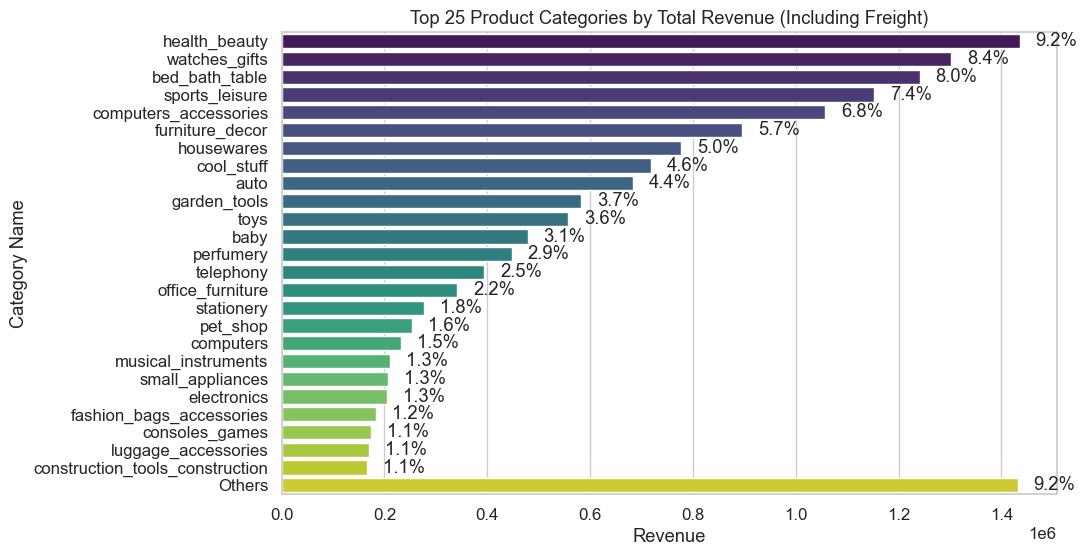

In [34]:
N = 25  # Top N categories

# Group by category
category_revenue = (
    orders_products.groupby("product_category_name")["total_price"]
    .sum()
    .reset_index()
    .rename(columns={"total_price": "revenue"})
    .sort_values(by="revenue", ascending=False)
)

# Top N + Others
topN = category_revenue.head(N)
others = pd.DataFrame({
    "product_category_name": ["Others"],
    "revenue": [category_revenue["revenue"].iloc[N:].sum()]
})
category_plot = pd.concat([topN, others], ignore_index=True)

# Plot
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=category_plot,
    x="revenue",
    y="product_category_name",
    hue="product_category_name",
    palette="viridis",
    legend=False
)

# Add % contribution
total_revenue = category_plot["revenue"].sum()
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    percentage = width / total_revenue * 100
    ax.text(width + total_revenue*0.002, y, f"{percentage:.1f}%", va="center")

plt.title(f"Top {N} Product Categories by Total Revenue (Including Freight)")
plt.xlabel("Revenue")
plt.ylabel("Category Name")
plt.show()

**Insight:** Repeating the top-category analysis using total_price (product price + freight) shows virtually no change in the revenue ranking. This indicates that shipping costs are relatively consistent across categories and do not materially impact category revenue, confirming that product price is the main driver of revenue.
This also justifies focusing on price alone in future category-based analyses or dashboards.

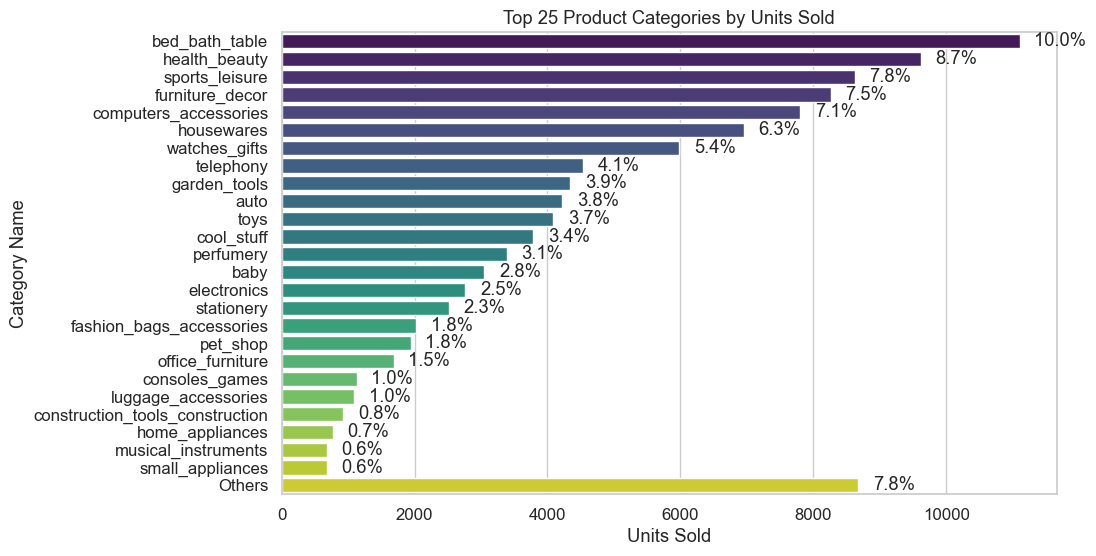

In [35]:
# Checking Units Sold 

# Counting number of items sold per category
category_units = (
    orders_products.groupby("product_category_name")["order_item_id"]
    .count()
    .reset_index()
    .rename(columns={"order_item_id": "units_sold"})
    .sort_values(by="units_sold", ascending=False)
)

# Top N + Others (same N as before)
topN = category_units.head(N)
others = pd.DataFrame({
    "product_category_name": ["Others"],
    "units_sold": [category_units["units_sold"].iloc[N:].sum()]
})
category_units_plot = pd.concat([topN, others], ignore_index=True)

# Plot
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=category_units_plot,
    x="units_sold",
    y="product_category_name",
    hue="product_category_name",
    palette="viridis",
    legend=False
)

# Add % contribution
total_units = category_units_plot["units_sold"].sum()
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    percentage = width / total_units * 100
    ax.text(width + total_units*0.002, y, f"{percentage:.1f}%", va="center")

plt.title(f"Top {N} Product Categories by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Category Name")
plt.show()

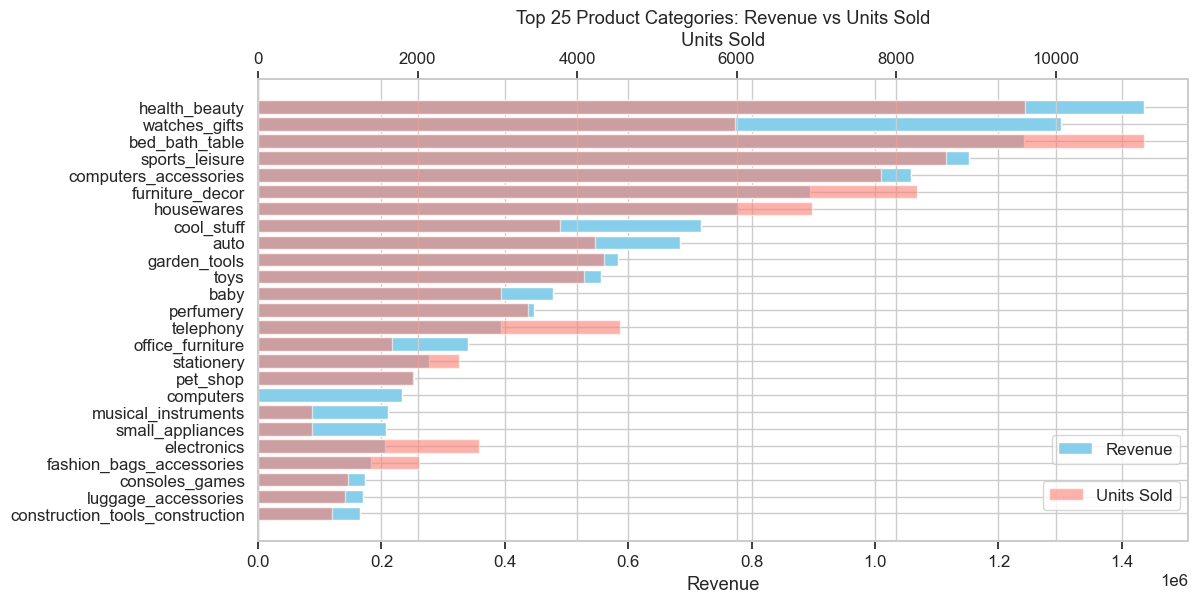

In [36]:
# Units Sold X Revenue

# Preparing data for Top N categories (based on revenue)
top_categories = category_plot[category_plot['product_category_name'] != 'Others']
top_units = category_units_plot[category_units_plot['product_category_name'].isin(top_categories['product_category_name'])]

comparison_df = top_categories.merge(
    top_units,
    on='product_category_name',
    how='left'
)

# Plot dual-axis horizontal bar chart
fig, ax1 = plt.subplots(figsize=(12,6))

y_pos = np.arange(len(comparison_df))

# Revenue bars on primary x-axis
ax1.barh(y_pos, comparison_df['revenue'], color='skyblue', label='Revenue')
ax1.set_xlabel('Revenue')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(comparison_df['product_category_name'])
ax1.invert_yaxis()  # highest on top

# Units Sold on secondary x-axis
ax2 = ax1.twiny()
ax2.barh(y_pos, comparison_df['units_sold'], color='salmon', alpha=0.6, label='Units Sold')
ax2.set_xlabel('Units Sold')

# Title
plt.title(f"Top {len(comparison_df)} Product Categories: Revenue vs Units Sold")

# Legends
ax1.legend(loc='lower right', bbox_to_anchor=(1, 0.15))  
ax2.legend(loc='lower right', bbox_to_anchor=(1, 0.05))

plt.show()

**Insight:** Comparing revenue and units sold by category reveals two distinct patterns:

**High revenue, low units sold:** Categories like watches_gifts, healthy_beauty, cool_stuff, and especially computers generate significant revenue despite selling fewer units. This suggests higher-priced or premium products driving revenue.

**High units sold, lower revenue:** Categories such as bed_bath_table, furniture_decor, and telephony sell many items but contribute less revenue per unit, indicating lower-priced or high-volume products.

**Business implication:** Understanding these patterns can guide decisions on pricing, promotions, inventory, and marketing focus, emphasizing high-margin products while managing high-volume categories efficiently.

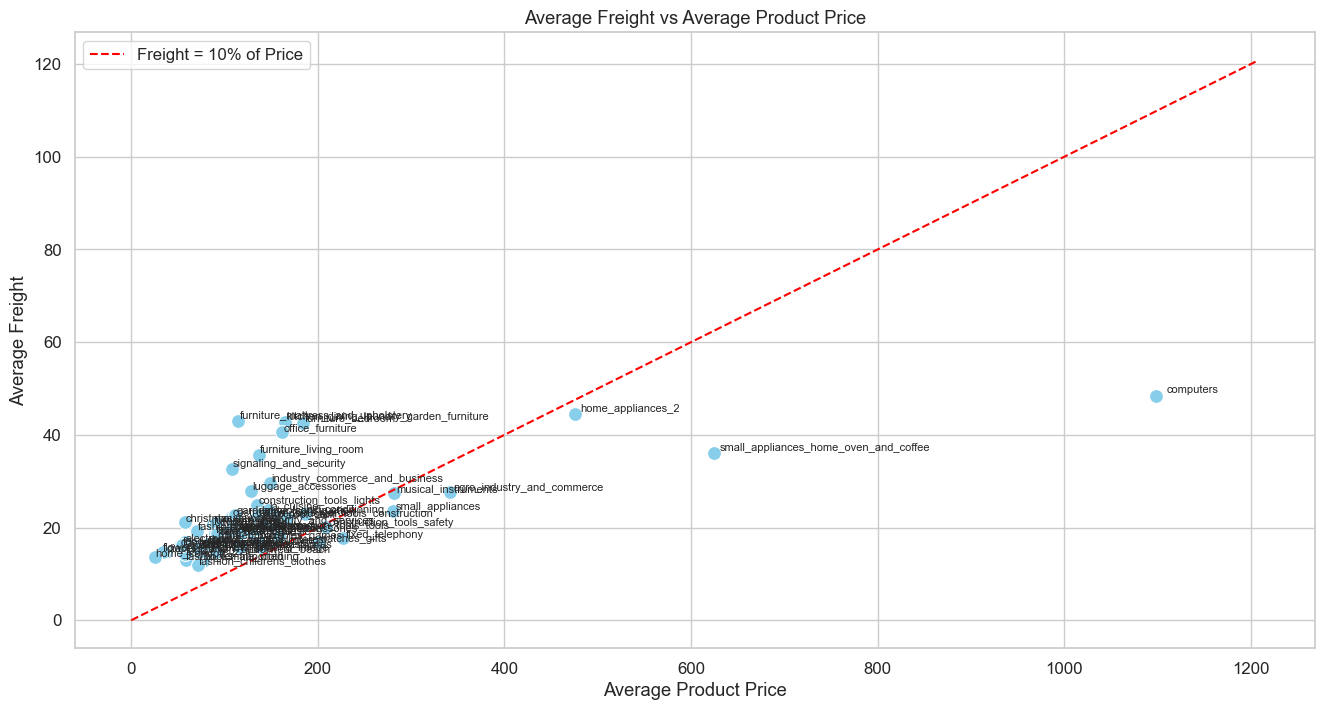

In [37]:
# Checking Freight vs Product Price per Category

category_price_freight = orders_products.groupby("product_category_name").agg(
                                                                              avg_price=("price", "mean"),
                                                                              avg_freight=("freight_value", "mean")
                                                                              ).reset_index()

# Compute freight ratio
category_price_freight['freight_ratio'] = category_price_freight['avg_freight'] / category_price_freight['avg_price']

# Plot
plt.figure(figsize=(16,8))
sns.scatterplot(
    data=category_price_freight,
    x="avg_price",
    y="avg_freight",
    s=100,
    color='skyblue'
)

# Draw diagonal-like threshold line (y = threshold * x)
threshold = 0.1
x_vals = np.linspace(0, category_price_freight['avg_price'].max()*1.1, 100)
plt.plot(x_vals, threshold*x_vals, color='red', linestyle='--', label=f'Freight = {threshold*100:.0f}% of Price')

# Annotate all categories
for i, row in category_price_freight.iterrows():
    plt.text(row["avg_price"]*1.01, row["avg_freight"]*1.01, row["product_category_name"], fontsize=8)

plt.title("Average Freight vs Average Product Price")
plt.xlabel("Average Product Price")
plt.ylabel("Average Freight")
plt.legend()
plt.show()

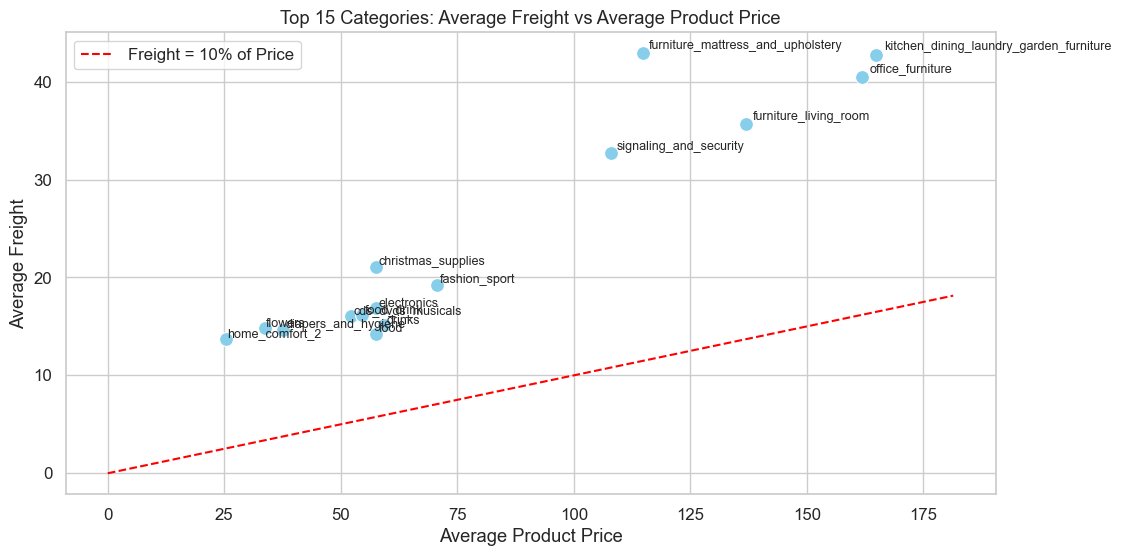

In [38]:
# Checking just Top N products with a higher freight-to-price ratio

# Compute freight ratio
category_price_freight['freight_ratio'] = category_price_freight['avg_freight'] / category_price_freight['avg_price']

# Select top N categories by freight_ratio
N = 15
top_categories = category_price_freight.sort_values('freight_ratio', ascending=False).head(N)

# Plot
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=top_categories,
    x="avg_price",
    y="avg_freight",
    s=100,
    color='skyblue'
)

# Draw diagonal-like threshold line (y = threshold * x)
threshold = 0.10
x_vals = np.linspace(0, top_categories['avg_price'].max()*1.1, 100)
plt.plot(x_vals, threshold*x_vals, color='red', linestyle='--', label=f'Freight = {threshold*100:.0f}% of Price')

# Annotate points
for i, row in top_categories.iterrows():
    plt.text(row["avg_price"]*1.01, row["avg_freight"]*1.01, row["product_category_name"], fontsize=9)

plt.title(f"Top {N} Categories: Average Freight vs Average Product Price")
plt.xlabel("Average Product Price")
plt.ylabel("Average Freight")
plt.legend()
plt.show()

**Insight:** The freight-to-price ratio doesn't vary significantly across categories, with a few exceptions. High-priced categories like computers and small_appliances_home_oven_and_coffee have the lowest ratios, meaning shipping is relatively cheap compared to product value. Conversely, several furniture-related categories show the highest ratios, despite not having low average prices, indicating that shipping costs could disproportionately impact purchases in these segments.

**Insight 2:** The computers category has relatively few units sold and a low freight-to-price ratio, making it logistically efficient. Although it ranks 18th out of 71 in total revenue, its combination of higher product prices and efficient shipping suggests it is a strategically important category for the marketplace to focus on.

In [39]:
# Checking the effect of Product Description and Number of Photos on Units Sold

# Compute correlation between description length, number of photos, and units sold
correlation_data = orders_products[['product_description_lenght', 'product_photos_qty', 'order_item_id']].copy()
# Assuming 'order_item_id' is per unit sold; otherwise, aggregate units sold per product
correlation_data.rename(columns={'order_item_id': 'units_sold'}, inplace=True)

correlation_matrix = correlation_data.corr()
print(correlation_matrix)

                            product_description_lenght  product_photos_qty  \
product_description_lenght                        1.00                0.12   
product_photos_qty                                0.12                1.00   
units_sold                                       -0.01               -0.06   

                            units_sold  
product_description_lenght       -0.01  
product_photos_qty               -0.06  
units_sold                        1.00  


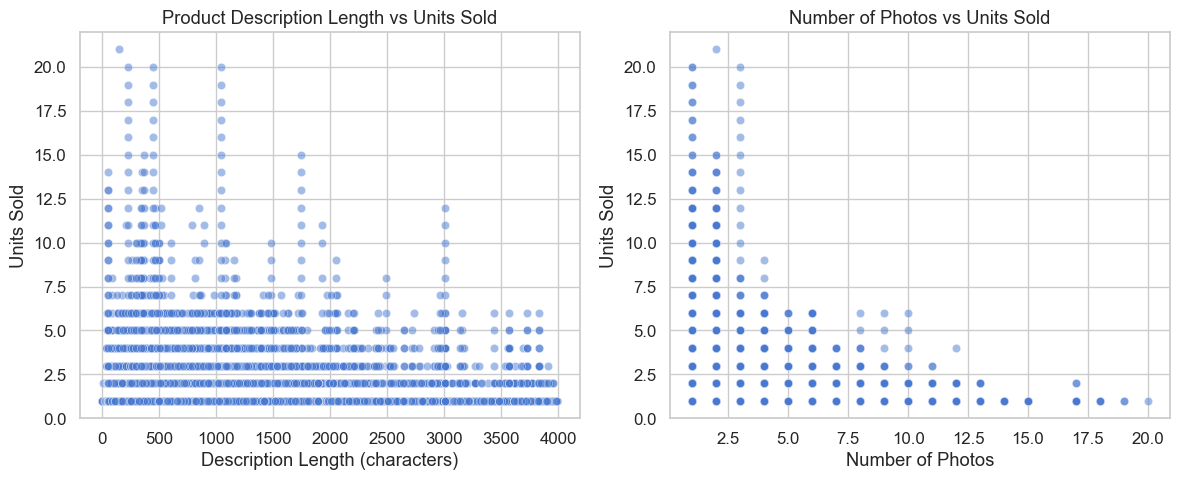

In [40]:
plt.figure(figsize=(12,5))

# Description length vs units sold
plt.subplot(1,2,1)
sns.scatterplot(x='product_description_lenght', y='units_sold', data=correlation_data, alpha=0.5)
plt.title('Product Description Length vs Units Sold')
plt.xlabel('Description Length (characters)')
plt.ylabel('Units Sold')

# Number of photos vs units sold
plt.subplot(1,2,2)
sns.scatterplot(x='product_photos_qty', y='units_sold', data=correlation_data, alpha=0.5)
plt.title('Number of Photos vs Units Sold')
plt.xlabel('Number of Photos')
plt.ylabel('Units Sold')

plt.tight_layout()
plt.show()

In [41]:
photo_counts = orders_products['product_photos_qty'].value_counts().sort_index()
photo_counts

product_photos_qty
1.00     55870
2.00     21872
3.00     12346
4.00      8406
5.00      5356
6.00      3771
7.00      1498
8.00       718
9.00       313
10.00      341
11.00       68
12.00       53
13.00       30
14.00        6
15.00       12
17.00       11
18.00        4
19.00        2
20.00        1
Name: count, dtype: int64

       units_sold  num_photos
count    1,798.00    1,798.00
mean         3.80        7.19
std         14.78        1.87
min          1.00        6.00
25%          1.00        6.00
50%          1.00        6.00
75%          3.00        8.00
max        527.00       20.00


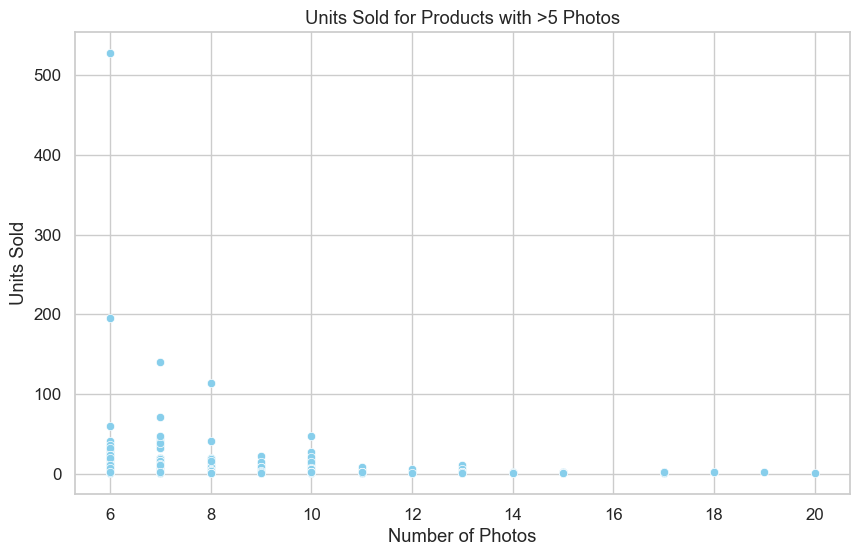

In [42]:
# Selecting top 10% of photo counts
high_photo_threshold = orders_products['product_photos_qty'].quantile(0.9)
high_photo_products = orders_products[orders_products['product_photos_qty'] > high_photo_threshold]

# Aggregate units sold per product
high_photo_summary = high_photo_products.groupby('product_id').agg(
    units_sold=('order_item_id', 'count'),
    num_photos=('product_photos_qty', 'max') 
).reset_index()

# Quick summary stats
print(high_photo_summary.describe())

# Optional: scatter plot for visualization
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='num_photos',
    y='units_sold',
    data=high_photo_summary,
    color='skyblue'
)
plt.title(f"Units Sold for Products with >{high_photo_threshold:.0f} Photos")
plt.xlabel("Number of Photos")
plt.ylabel("Units Sold")
plt.show()

**Insight:** Neither product description length nor number of photos shows a meaningful correlation with units sold. Most products have 1–3 photos, and even products with unusually many photos do not sell more; similarly, longer descriptions do not increase sales. This suggests that product presentation alone is not a key driver of purchase behavior in this marketplace.

# Orders and Payments

In [43]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [44]:
payments_summary = payments.groupby('payment_type').agg(
    total_revenue=('payment_value', 'sum'),
    average_payment=('payment_value', 'mean'),
    count=('payment_value', 'count')
).sort_values(by='total_revenue', ascending=False)

# Adding percentage columns
payments_summary['%_of_total_revenue'] = (payments_summary['total_revenue'] / payments_summary['total_revenue'].sum() * 100)

payments_summary['%_of_total_count'] = (payments_summary['count'] / payments_summary['count'].sum() * 100)

payments_summary

,total_revenue,average_payment,count,%_of_total_revenue,%_of_total_count
payment_type,,,,,
credit_card,"12,542,084.19",163.32,76795,78.34,73.92
boleto,"2,869,361.27",145.03,19784,17.92,19.04
voucher,"379,436.87",65.70,5775,2.37,5.56
debit_card,"217,989.79",142.57,1529,1.36,1.47
not_defined,0.00,0.00,3,0.00,0.00


**Note**: The payment_type value “boleto” is a Brazilian bank slip (invoice) that can be paid at banks, online banking, or authorized payment locations. It’s similar to a bill payment and is commonly used for offline payments.

In [45]:
installments_counts = payments['payment_installments'].value_counts().sort_index().reset_index()
installments_counts.columns = ['payment_installments', 'count']

# Calculating percentage
installments_counts['percentage'] = (installments_counts['count'] / installments_counts['count'].sum() * 100).round(2)

installments_counts

,payment_installments,count,percentage
0,0,2,0.00
1,1,52546,50.58
2,2,12413,11.95
3,3,10461,10.07
4,4,7098,6.83
5,5,5239,5.04
6,6,3920,3.77
7,7,1626,1.57
8,8,4268,4.11
9,9,644,0.62


In [46]:
# Merging orders_products with payments
orders_payments = orders_products.merge(payments,
                                        on='order_id',
                                        how='left'
                                        )

orders_payments.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,housewares,40.00,268.00,4.00,500.00,19.00,8.00,13.00,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,housewares,40.00,268.00,4.00,500.00,19.00,8.00,13.00,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,housewares,40.00,268.00,4.00,500.00,19.00,8.00,13.00,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,perfumery,29.00,178.00,1.00,400.00,19.00,13.00,19.00,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,auto,46.00,232.00,1.00,420.00,24.00,19.00,21.00,1,credit_card,3,179.12


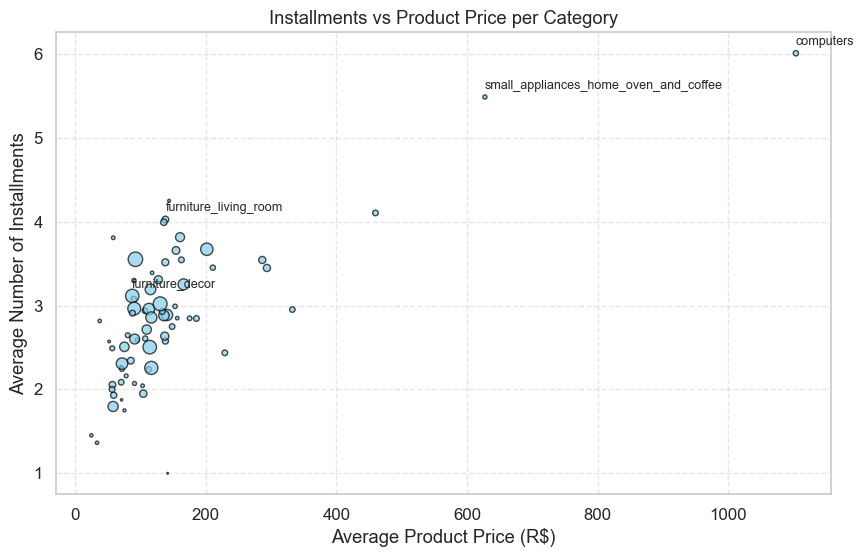

In [47]:
# Checking Payment Installments vs. Product Price

# Group by category to get avg price and avg installments
category_payment = (
                    orders_payments.groupby("product_category_name")
                    .agg(
                        avg_price=("price", "mean"),
                        avg_installments=("payment_installments", "mean"),
                        count=("order_id", "count")
                        ).reset_index()
                     )

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(
    category_payment["avg_price"],
    category_payment["avg_installments"],
    s=category_payment["count"]**0.5,  # bubble size ~ number of orders
    alpha=0.7,
    color="skyblue",
    edgecolor="black"
            )

# Highlight some categories
highlight = ["computers", "furniture_decor", "furniture_living_room", "small_appliances_home_oven_and_coffee"]
for cat in highlight:
    if cat in category_payment["product_category_name"].values:
        row = category_payment[category_payment["product_category_name"] == cat]
        plt.text(
            row["avg_price"].values[0],
            row["avg_installments"].values[0] + 0.1,
            cat,
            fontsize=9
                  )


plt.xlabel("Average Product Price (R$)")
plt.ylabel("Average Number of Installments")
plt.title("Installments vs Product Price per Category")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [48]:
installments_summary = orders_payments.groupby('payment_installments').agg(
                                                                            avg_payment=('payment_value','mean'),
                                                                            total_revenue=('payment_value','sum'),
                                                                            num_orders=('payment_value','count')
                                                                            ).sort_index()

# Adding percentage columns
installments_summary['%_revenue'] = (installments_summary['total_revenue'] / installments_summary['total_revenue'].sum() * 100)

installments_summary['%_orders'] = (installments_summary['num_orders'] / installments_summary['num_orders'].sum() * 100)

installments_summary

,avg_payment,total_revenue,num_orders,%_revenue,%_orders
payment_installments,,,,,
0,106.19,318.57,3,0.00,0.00
1,132.49,"7,808,640.09",58936,38.30,49.94
2,134.56,"1,851,425.25",13759,9.08,11.66
3,153.85,"1,809,707.95",11763,8.88,9.97
4,179.24,"1,433,773.75",7999,7.03,6.78
5,197.53,"1,190,911.60",6029,5.84,5.11
6,234.87,"1,084,855.35",4619,5.32,3.91
7,194.52,"354,410.53",1822,1.74,1.54
8,310.68,"1,576,088.05",5073,7.73,4.30


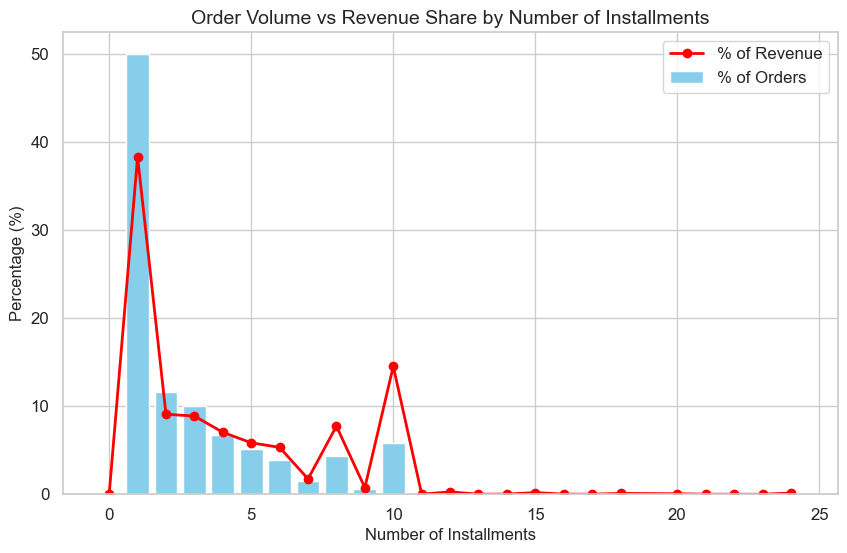

In [49]:
# Plot
plt.figure(figsize=(10,6))

# Bars: % of Orders
plt.bar(
        installments_summary.index, 
        installments_summary['%_orders'], 
        color='skyblue', 
        label='% of Orders'
         )

# Line: % of Revenue
plt.plot(
         installments_summary.index, 
         installments_summary['%_revenue'], 
         color='red', marker='o', linewidth=2, label='% of Revenue'
         )

# Labels & title
plt.xlabel("Number of Installments", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.title("Order Volume vs Revenue Share by Number of Installments", fontsize=14)
plt.legend()
plt.show()

**Insight:** Most orders are paid in a single installment (~50%), but they account for only 38% of total revenue, indicating these are smaller transactions. Conversely, orders paid in 8 and 10 installments, while only ~10% of total orders, contribute over 22% of revenue. This highlights that installment plans are key for enabling higher-value purchases.

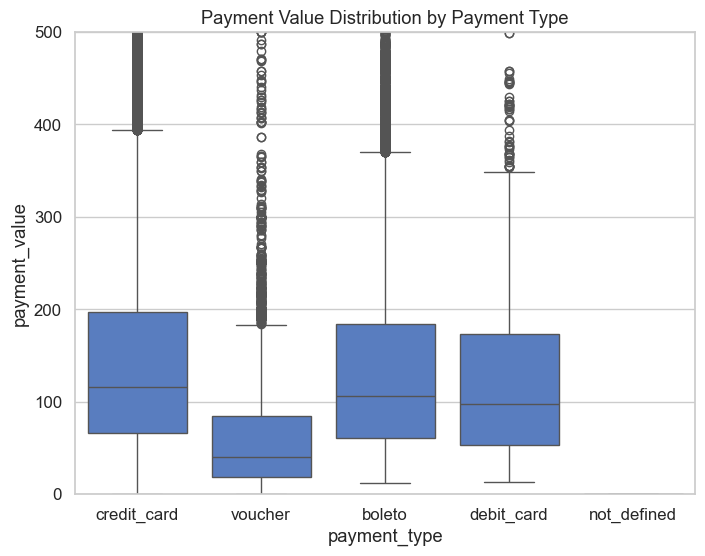

In [50]:
# Payment Type by Order Size

plt.figure(figsize=(8,6))
sns.boxplot(data=orders_payments, x='payment_type', y='payment_value')
plt.ylim(0, 500)  # cap to reduce outlier distortion
plt.title("Payment Value Distribution by Payment Type")
plt.show()

In [51]:
# Summary statistics
payment_stats = orders_payments.groupby('payment_type')['payment_value'].agg(
                                                                            count='count',
                                                                            total_revenue='sum',
                                                                            mean='mean',
                                                                            median='median',
                                                                            q1=lambda x: x.quantile(0.25),
                                                                            q3=lambda x: x.quantile(0.75),
                                                                            max='max'
                                                                             ).sort_values(by='total_revenue', ascending=False)

# Adding percentages
payment_stats['% of total revenue'] = payment_stats['total_revenue'] / payment_stats['total_revenue'].sum() * 100
payment_stats['% of total orders'] = payment_stats['count'] / payment_stats['count'].sum() * 100

payment_stats

,count,total_revenue,mean,median,q1,q3,max,% of total revenue,% of total orders
payment_type,,,,,,,,,
credit_card,86985,"15,634,062.69",179.73,115.34,65.57,196.99,"13,664.08",76.68,73.71
boleto,22961,"4,072,236.40",177.35,105.77,60.14,183.95,"7,274.88",19.97,19.46
voucher,6364,"426,630.02",67.04,40.14,18.19,84.25,"3,184.34",2.09,5.39
debit_card,1696,"256,176.19",151.05,97.51,53.47,172.71,"4,445.50",1.26,1.44
not_defined,2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [52]:
#Checking top 10% payments in value

# Defining high-value threshold (e.g., top 10% of all payments)
high_value_threshold = orders_payments['payment_value'].quantile(0.90)

# Flagging high-value orders
orders_payments['high_value'] = orders_payments['payment_value'] >= high_value_threshold

# Calculate % of high-value orders per payment type
high_value_share = orders_payments.groupby('payment_type')['high_value'].mean().sort_values(ascending=False) * 100

high_value_share = high_value_share.reset_index().rename(columns={'high_value': '% high-value orders'})
high_value_share

,payment_type,% high-value orders
0,credit_card,10.65
1,boleto,10.11
2,debit_card,6.25
3,voucher,1.71
4,not_defined,0.00


**Insight:** Credit cards dominate this marketplace, accounting for over 73% of all orders and nearly 77% of total revenue. Boleto follows as the second most common payment type, but at a much smaller scale. Voucher and debit card payments represent only a small fraction of orders and revenue. The share of high-value orders is roughly proportional across payment types, indicating that no payment method is strongly associated with larger transactions; the main takeaway is that credit cards are the primary choice for customers.

# Time Analysis

In [53]:
revenue_trend = (
                 orders_payments.groupby(orders_payments['order_purchase_timestamp'].dt.to_period('M'))
                .agg(total_revenue=('payment_value', 'sum'), num_orders=('order_id', 'nunique'))
                .reset_index()
                 )

revenue_trend['order_purchase_timestamp'] = revenue_trend['order_purchase_timestamp'].dt.to_timestamp()
revenue_trend

,order_purchase_timestamp,total_revenue,num_orders
0,2017-01-01,"189,015.66",800
1,2017-02-01,"349,701.93",1780
2,2017-03-01,"544,738.23",2682
3,2017-04-01,"510,891.55",2404
4,2017-05-01,"731,017.09",3700
5,2017-06-01,"608,891.38",3245
6,2017-07-01,"744,599.53",4026
7,2017-08-01,"876,129.37",4331
8,2017-09-01,"1,023,095.49",4285
9,2017-10-01,"1,031,505.53",4631


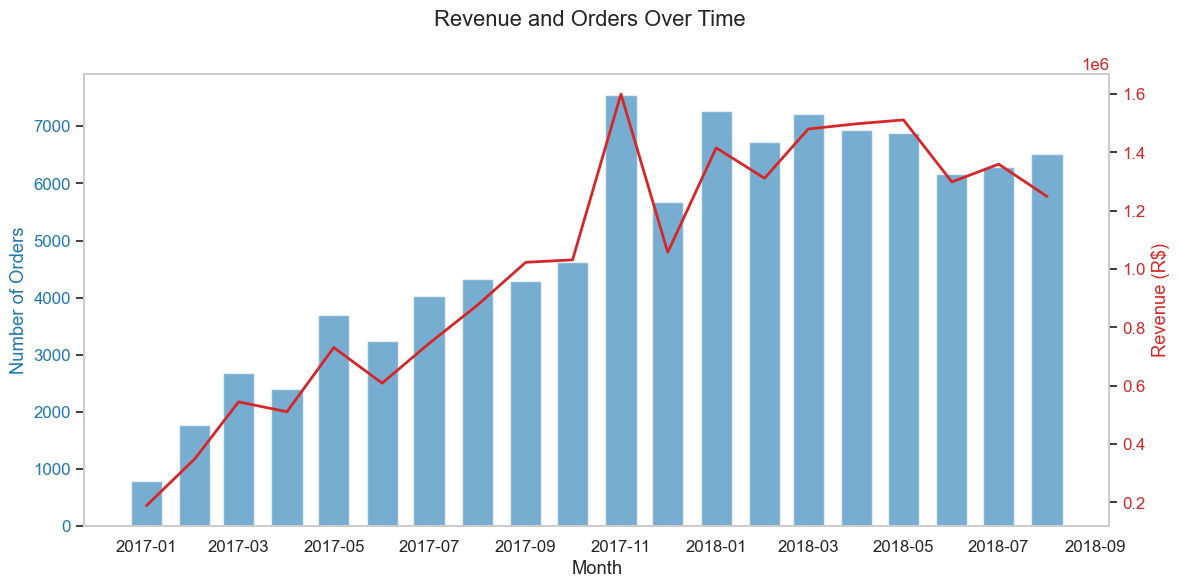

In [54]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Bars for orders
ax1.bar(revenue_trend['order_purchase_timestamp'], revenue_trend['num_orders'], 
        color='tab:blue', alpha=0.6, width=20, label='Number of Orders')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Orders', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Line for revenue
ax2 = ax1.twinx()
ax2.plot(revenue_trend['order_purchase_timestamp'], revenue_trend['total_revenue'], 
         color='tab:red', linewidth=2, label='Revenue')
ax2.set_ylabel('Revenue (R$)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Title and layout
fig.suptitle('Revenue and Orders Over Time')
fig.tight_layout()
ax1.grid(False)
ax2.grid(False)
plt.show()

In [55]:
payment_trend = (
                 orders_payments
                 .groupby([orders_payments['order_purchase_timestamp'].dt.to_period('M'),'payment_type'])
                 .agg(total_revenue=('payment_value', 'sum'))
                 .reset_index()
                 )

payment_trend['order_purchase_timestamp'] = payment_trend['order_purchase_timestamp'].dt.to_timestamp()
payment_trend

,order_purchase_timestamp,payment_type,total_revenue
0,2017-01-01,boleto,"33,403.05"
1,2017-01-01,credit_card,"149,353.99"
2,2017-01-01,debit_card,788.19
3,2017-01-01,voucher,"5,470.43"
4,2017-02-01,boleto,"73,826.06"
...,...,...,...
76,2018-08-01,boleto,"172,583.94"
77,2018-08-01,credit_card,"986,399.71"
78,2018-08-01,debit_card,"52,322.33"
79,2018-08-01,not_defined,0.00


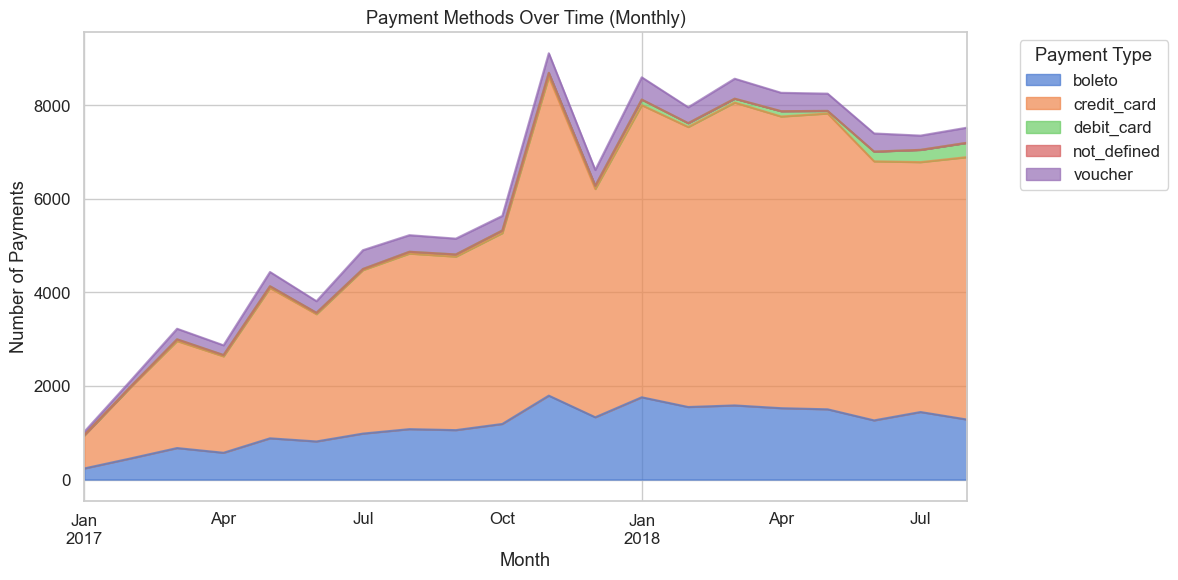

In [56]:
# Payment Methods Over Time
payment_trend = (
                 orders_payments
                 .groupby([pd.Grouper(key='order_purchase_timestamp', freq='ME'), 'payment_type'])
                 .size()
                 .unstack(fill_value=0)
                 )

# Plot stacked area
fig, ax = plt.subplots(figsize=(12,6))
payment_trend.plot.area(ax=ax, alpha=0.7)

ax.set_title('Payment Methods Over Time (Monthly)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Payments')
ax.legend(title='Payment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

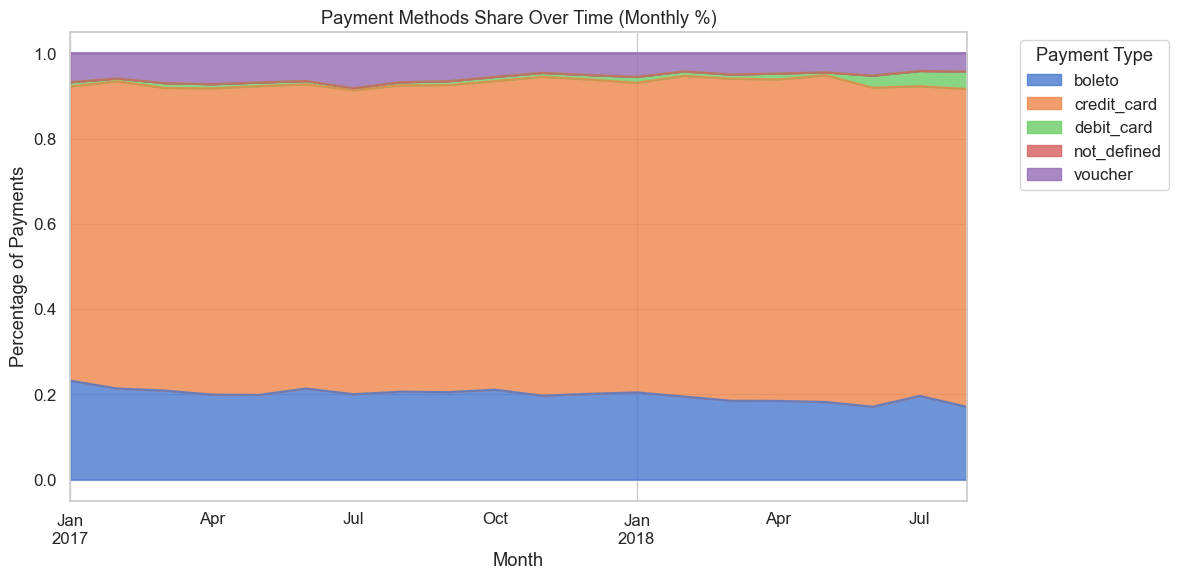

In [57]:
# Payment Methods Over Time as %
payment_trend_normalized = payment_trend.div(payment_trend.sum(axis=1), axis=0)

# Plot normalized stacked area chart
fig, ax = plt.subplots(figsize=(12,6))
payment_trend_normalized.plot.area(ax=ax, alpha=0.8)

ax.set_title('Payment Methods Share Over Time (Monthly %)')
ax.set_xlabel('Month')
ax.set_ylabel('Percentage of Payments')
ax.legend(title='Payment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Insight:** The distribution of payment methods remained fairly stable throughout the observed period, with credit card and boleto consistently dominating. A slight increase in debit card usage is visible in the final months, but it still represents only a small share overall. No major shifts in customer payment preferences were identified.

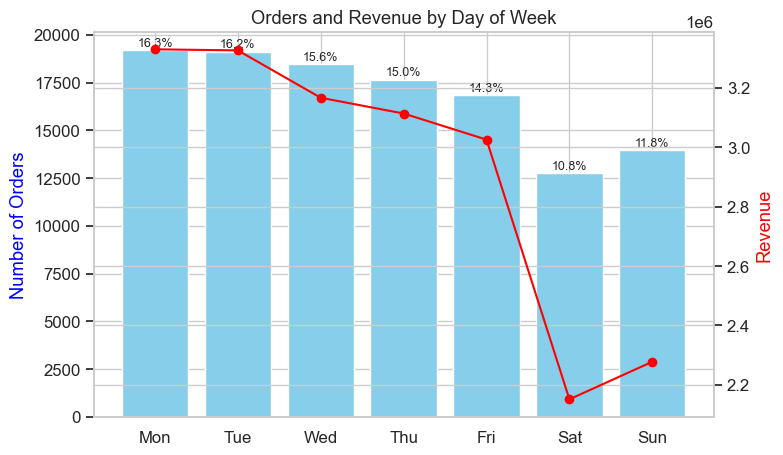

In [58]:
# Checking orders and revenue by day of the week

# Extract weekday (0=Monday, 6=Sunday)
orders_payments['day_of_week'] = orders_payments['order_purchase_timestamp'].dt.dayofweek

# Aggregate by day of week
dow_summary = orders_payments.groupby('day_of_week').agg(
                                                         total_orders=('order_id', 'count'),
                                                         total_revenue=('payment_value', 'sum')
                                                         ).reset_index()

# Map day numbers to names
dow_summary['day_name'] = dow_summary['day_of_week'].map({
                                                          0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'
                                                          })

# Sort by weekday order
dow_summary = dow_summary.sort_values('day_of_week')

# Adding %
dow_summary['orders_pct'] = dow_summary['total_orders'] / dow_summary['total_orders'].sum() * 100

# Plot 
fig, ax1 = plt.subplots(figsize=(8,5))

bars = ax1.bar(dow_summary['day_name'], dow_summary['total_orders'], color='skyblue', label='Orders')
ax1.set_ylabel("Number of Orders", color="blue")

# Annotate % on top of each bar
for bar, pct in zip(bars, dow_summary['orders_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(dow_summary['day_name'], dow_summary['total_revenue'], color="red", marker="o", label="Revenue")
ax2.set_ylabel("Revenue", color="red")

plt.title("Orders and Revenue by Day of Week")
plt.show()

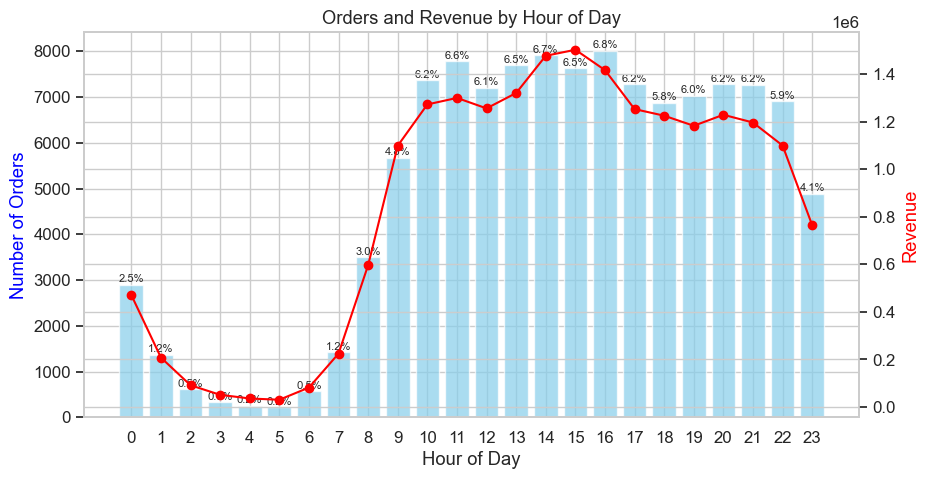

In [59]:
# Checking orders and revenue by hour of the day

# Extract hour
orders_payments['hour'] = orders_payments['order_purchase_timestamp'].dt.hour

# Aggregate by hour
hour_summary = orders_payments.groupby('hour').agg(
                                                   total_orders=('order_id', 'count'),
                                                   total_revenue=('payment_value', 'sum')
                                                    ).reset_index()

# Adding %
hour_summary['orders_pct'] = hour_summary['total_orders'] / hour_summary['total_orders'].sum() * 100

# Plot 
fig, ax1 = plt.subplots(figsize=(10,5))

bars = ax1.bar(hour_summary['hour'], hour_summary['total_orders'], color='skyblue', alpha=0.7, label='Orders')
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Number of Orders", color="blue")

# Annotate % on top of each bar
for bar, pct in zip(bars, hour_summary['orders_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f"{pct:.1f}%", ha='center', va='bottom', fontsize=8)

ax2 = ax1.twinx()
ax2.plot(hour_summary['hour'], hour_summary['total_revenue'], color="red", marker="o", label="Revenue")
ax2.set_ylabel("Revenue", color="red")

plt.title("Orders and Revenue by Hour of Day")
plt.xticks(range(0,24))
plt.show()

**Insight** – Order Patterns by Day and Hour:

Day of the week: Most orders occur on weekdays, with Monday (16.3%) and Tuesday (16.2%) being the busiest. Weekend orders drop noticeably, especially on Saturday (10.8%).

Hour of the day: Orders are fairly evenly distributed between 10 AM and 10 PM (~5.8–6.8% per hour), with a clear peak between 2 PM and 4 PM. This indicates that customers mostly shop during typical daytime hours, with afternoons being the busiest.

# Merging Orders and Reviews

In [60]:
orders_reviews = orders_products.merge(reviews, on="order_id", how="left")

orders_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,housewares,40.00,268.00,4.00,500.00,19.00,8.00,13.00,a54f0611adc9ed256b57ede6b6eb5114,4.00,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,perfumery,29.00,178.00,1.00,400.00,19.00,13.00,19.00,8d5266042046a06655c8db133d120ba5,4.00,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,auto,46.00,232.00,1.00,420.00,24.00,19.00,21.00,e73b67b67587f7644d5bd1a52deb1b01,5.00,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,1.00,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00,359d03e676b3c069f62cadba8dd3f6e8,5.00,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,1.00,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,stationery,38.00,316.00,4.00,250.00,51.00,15.00,15.00,e50934924e227544ba8246aeb3770dd4,5.00,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


              count  % of total
review_score                   
1.00          14653       13.00
2.00           3919        3.48
3.00           9448        8.38
4.00          21292       18.89
5.00          63414       56.25


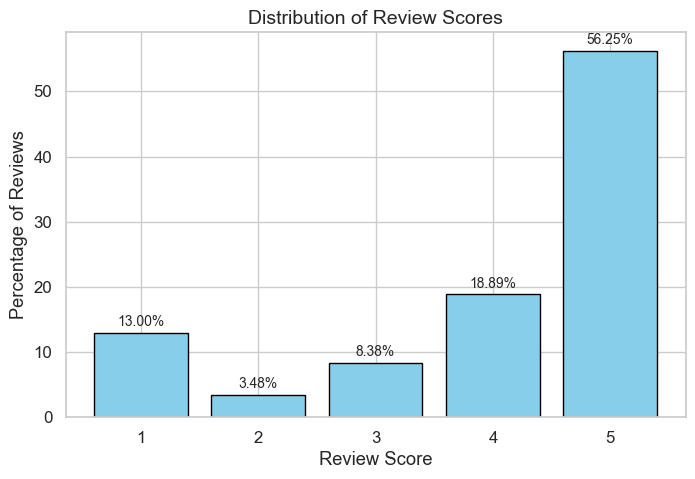

In [61]:
review_counts = orders_reviews['review_score'].value_counts().sort_index()
review_percentages = review_counts / review_counts.sum() * 100
review_counts_df = pd.DataFrame({'count': review_counts, '% of total': review_percentages})
print(review_counts_df)

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(review_counts.index, review_percentages.values, color="skyblue", edgecolor="black")

# Add percentage labels on top
for bar, pct in zip(bars, review_percentages.values):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{pct:.2f}%", 
             ha='center', va='bottom', fontsize=10)

plt.title("Distribution of Review Scores", fontsize=14)
plt.xlabel("Review Score")
plt.ylabel("Percentage of Reviews")
plt.xticks(review_counts.index)
plt.show()

product_category_name
cds_dvds_musicals           4.64
fashion_childrens_clothes   4.50
books_general_interest      4.45
costruction_tools_tools     4.44
flowers                     4.42
                            ... 
fashion_male_clothing       3.66
home_comfort_2              3.63
office_furniture            3.50
diapers_and_hygiene         3.21
security_and_services       2.50
Name: review_score, Length: 71, dtype: float64


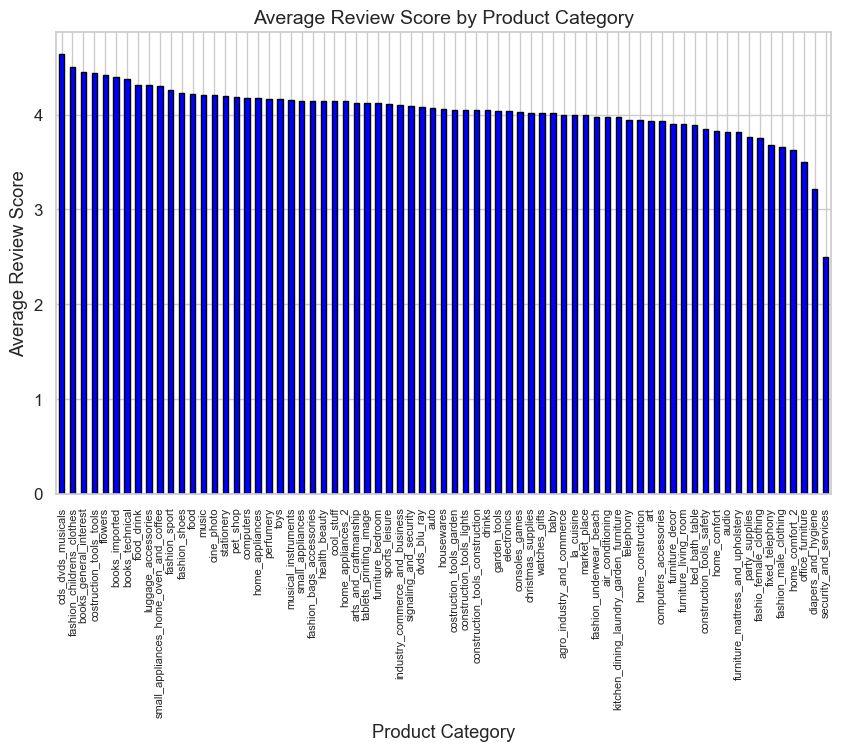

In [62]:
# Checking Reviews by Product Category

category_reviews = orders_reviews.groupby("product_category_name")["review_score"].mean().sort_values(ascending=False)
print(category_reviews)

plt.figure(figsize=(10,6))
category_reviews.plot(kind="bar", color="blue", edgecolor="black")
plt.title("Average Review Score by Product Category", fontsize=14)
plt.ylabel("Average Review Score")
plt.xlabel("Product Category")
plt.xticks(rotation=90, fontsize=8)
plt.show()

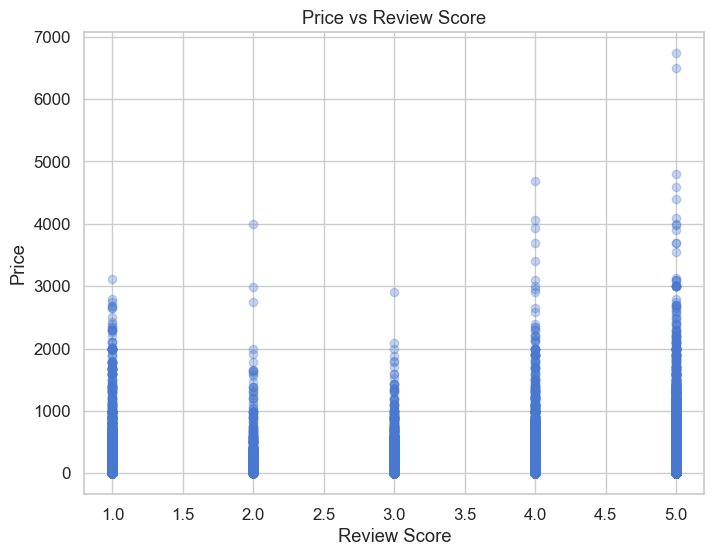

In [63]:
# Reviews by Product Price

plt.figure(figsize=(8,6))
plt.scatter(orders_reviews['review_score'], orders_reviews['price'], alpha=0.3)
plt.xlabel("Review Score")
plt.ylabel("Price")
plt.title("Price vs Review Score")
plt.show()

customer_state
AP   4.22
SP   4.11
TO   4.10
AC   4.10
PR   4.09
MG   4.07
RN   4.06
AM   4.06
RS   4.05
MS   4.03
DF   4.00
SC   3.99
PB   3.99
ES   3.98
GO   3.98
MT   3.98
RO   3.96
PE   3.95
PI   3.89
SE   3.80
BA   3.80
RJ   3.80
CE   3.79
PA   3.78
AL   3.72
MA   3.69
RR   3.67
Name: review_score, dtype: float64


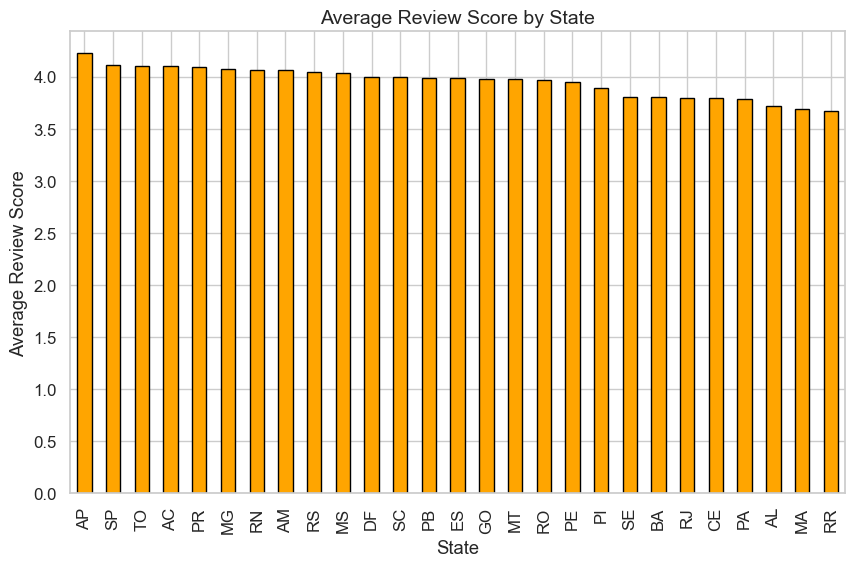

In [64]:
# Reviews by State

state_reviews = orders_reviews.groupby("customer_state")["review_score"].mean().sort_values(ascending=False)
print(state_reviews)

plt.figure(figsize=(10,6))
state_reviews.plot(kind="bar", color="orange", edgecolor="black")
plt.title("Average Review Score by State", fontsize=14)
plt.ylabel("Average Review Score")
plt.xlabel("State")
plt.show()

**Note** – Reviews by Category, Price, and State

**Product Categories:** Reviews are quite consistent across most categories (between 3.5 and 4.5 on average). However, there are two clear outliers:

Diapers and Hygiene (avg. 3.21)
Security and Services (avg. 2.5)

These much lower scores suggest either product dissatisfaction or mismatched expectations in these categories. On the other side, CDs, DVDs, and Musicals stand out positively, with an average of 4.64, the highest among all categories.

**Price vs. Reviews:** When comparing review scores against order price, no clear relationship emerges. Higher- or lower-priced items show similar review distributions, meaning that price does not seem to be a driver of satisfaction in this dataset.

**State Differences:** Average review scores are fairly homogeneous across states, with only minor variations. The highest averages come from Amapá (AP – 4.22) and São Paulo (SP – 4.11), while the lowest is Roraima (RR – 3.67). This suggests that, overall, geography does not strongly influence customer satisfaction.

**Insight:** Customer satisfaction is generally stable across categories, price levels, and states, but specific product categories (diapers, hygiene, and services) clearly underperform and may require attention from the business.

Average review scores by delivery status:
delivery_status
Late            2.55
Never Arrived   1.76
On-time         4.21
Name: review_score, dtype: float64

Percentage of each delivery status:
delivery_status
On-time         89.72
Late             7.59
Never Arrived    2.69
Name: proportion, dtype: float64


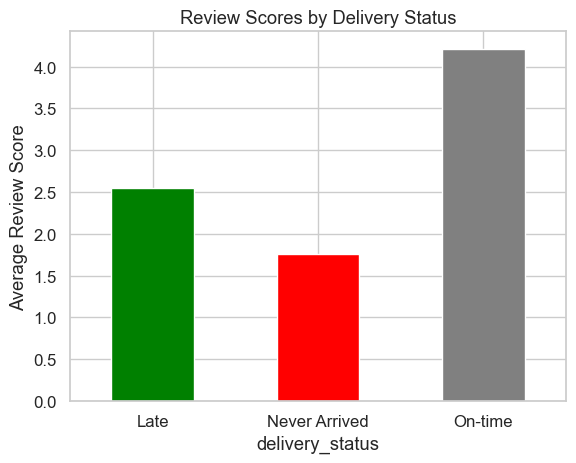

In [65]:
# Checking late-delivery vs. review score

# Creating a category column for [On-time, Late, Never Arrived]
def categorize_delivery(row):
    if pd.isna(row['order_delivered_customer_date']):
        return 'Never Arrived'
    elif row['order_delivered_customer_date'] > row['order_estimated_delivery_date']:
        return 'Late'
    else:
        return 'On-time'

orders_reviews['delivery_status'] = orders_reviews.apply(categorize_delivery, axis=1)

# Drop rows without review_score
df_valid = orders_reviews.dropna(subset=['review_score', 'order_estimated_delivery_date'])

# Group and compare average review scores
avg_scores = df_valid.groupby('delivery_status')['review_score'].mean()
counts = df_valid['delivery_status'].value_counts(normalize=True) * 100

print("Average review scores by delivery status:")
print(avg_scores)
print("\nPercentage of each delivery status:")
print(counts)

# Plot
avg_scores.plot(kind='bar', color=['green','red','gray'])
plt.xticks(rotation=0)
plt.ylabel('Average Review Score')
plt.title('Review Scores by Delivery Status')
plt.show()

**Insight Note** – Delivery Timeliness and Review Scores

- There's a clear and significant relationship between delivery performance and customer satisfaction:
    - On-time deliveries (≈ 89.7% of orders) receive an average review score of 4.21, indicating consistently positive feedback;
    - Late deliveries (≈ 7.6% of orders) see their average score drop sharply to 2.55, highlighting how delays strongly affect customer sentiment;
    - Orders that never arrived (≈ 2.7%) perform the worst, with an average review score of only 1.76.

This pattern suggests that delivery punctuality is one of the strongest drivers of customer satisfaction in Olist’s marketplace. Even a relatively small proportion of late or undelivered orders can severely damage ratings, reinforcing the importance of logistics reliability, tracking transparency, and proactive communication with customers.

Written reviews: 47859 (42.10%)
Average score (with comment): 3.55
Average score (without comment): 4.36


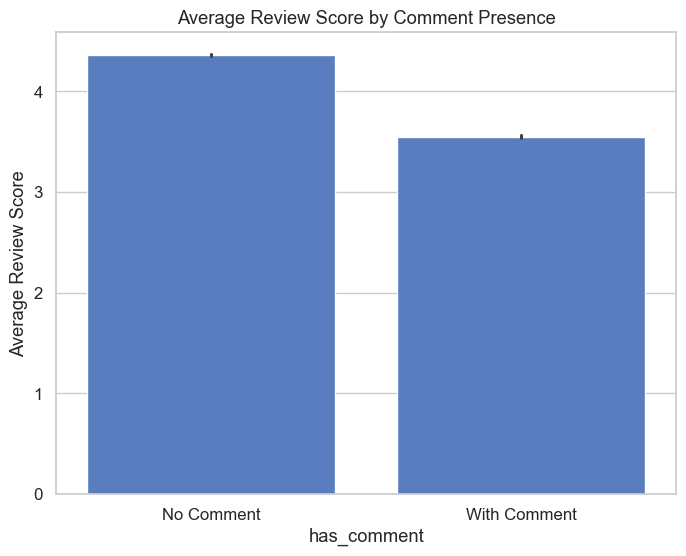

In [66]:
# Proportion of Written Reviews

total_reviews = len(orders_reviews)
written_reviews = orders_reviews['review_comment_message'].notna().sum()
pct_written = (written_reviews / total_reviews) * 100

print(f"Written reviews: {written_reviews} ({pct_written:.2f}%)")

# Comparing Scores With vs Without Comments

orders_reviews['has_comment'] = orders_reviews['review_comment_message'].notna()

avg_with_comment = orders_reviews[orders_reviews['has_comment']]['review_score'].mean()
avg_without_comment = orders_reviews[~orders_reviews['has_comment']]['review_score'].mean()

print("Average score (with comment):", round(avg_with_comment,2))
print("Average score (without comment):", round(avg_without_comment,2))

plt.figure(figsize=(8,6))
sns.barplot(x='has_comment', y='review_score', data=orders_reviews, estimator=lambda x: sum(x)/len(x))
plt.xticks([0,1], ['No Comment', 'With Comment'])
plt.ylabel("Average Review Score")
plt.title("Average Review Score by Comment Presence")
plt.show()

**Insight:** A significant portion of customers (almost half) are motivated to leave additional feedback beyond just the score. Customers are much more likely to leave a written review when they are dissatisfied. While satisfied customers often provide only a score (and usually a high one), dissatisfied customers tend to express their negative experiences in text. Customers are much more likely to leave a written review when they are dissatisfied. While satisfied customers often provide only a score (and usually a high one), dissatisfied customers tend to express their negative experiences in text. Mining these comments for recurring themes (e.g., delays, product quality, service issues) could provide actionable insights for improving customer satisfaction.

# Written Reviews Analysis

In [68]:
import nltk
import re
import unidecode
from nltk.corpus import stopwords
import spacy

In [69]:
# Load Portuguese stopwords
nltk.download('stopwords')
stopwords_pt = set(stopwords.words('portuguese'))

# Load spacy Portuguese model
nlp = spacy.load("pt_core_news_sm")

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = unidecode.unidecode(text)          # remove accents
    text = re.sub(r'[^a-z\s]', '', text)      # keep only letters
    tokens = [t.lemma_ for t in nlp(text)]    # lemmatization
    tokens = [t for t in tokens if t not in stopwords_pt and len(t) > 2]
    return " ".join(tokens)

# Apply to dataset
orders_reviews["review_clean"] = orders_reviews["review_comment_message"].apply(preprocess_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SAMSUNG\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [70]:
orders_reviews[orders_reviews['has_comment'] == True].head(15)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_status,has_comment,review_clean
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,housewares,40.00,268.00,4.00,500.00,19.00,8.00,13.00,a54f0611adc9ed256b57ede6b6eb5114,4.00,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,On-time,True,nao testar produto ainda vir correto bom Condi...
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,perfumery,29.00,178.00,1.00,400.00,19.00,13.00,19.00,8d5266042046a06655c8db133d120ba5,4.00,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,On-time,True,bom produto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,1.00,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00,359d03e676b3c069f62cadba8dd3f6e8,5.00,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,On-time,True,produto exatamente esperar descrito em o site ...
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,2017-04,1.00,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,2017-04-19 13:25:17,49.90,16.05,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,65.95,NaN,NaN,NaN,NaN,600.00,35.00,35.00,15.00,e07549ef5311abcc92ba1784b093fb56,2.00,NaN,fiquei triste por n ter me atendido.,2017-05-13 00:00:00,2017-05-13 20:25:42,Never Arrived,True,fiquei triste ter atender
10,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,2017-05,1.00,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,2017-05-22 19:50:18,99.00,30.53,f2a85dec752b8517b5e58a06ff3cd937,20780,rio de janeiro,RJ,129.53,garden_tools,36.00,450.00,1.00,"9,000.00",42.00,12.00,39.00,15898b543726a832d4137fbef5d1d00e,1.00,NaN,Aguardando retorno da loja,2017-05-30 00:00:00,2017-05-30 23:13:47,On-time,True,aguardar retorno de o loja
11,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,2017-05,2.00,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,2017-05-22 19:50:18,99.00,30.53,f2a85dec752b8517b5e58a06ff3cd937,20780,rio de janeiro,RJ,129.53,garden_tools,36.00,450.00,1.00,"9,000.00",42.00,12.00,39.00,15898b543726a832d4137fbef5d1d00e,1.00,NaN,Aguardando retorno da loja,2017-05-30 00:00:00,2017-05-30 23:13:47,On-time,True,aguardar retorno de o loja
15,432aaf21d8

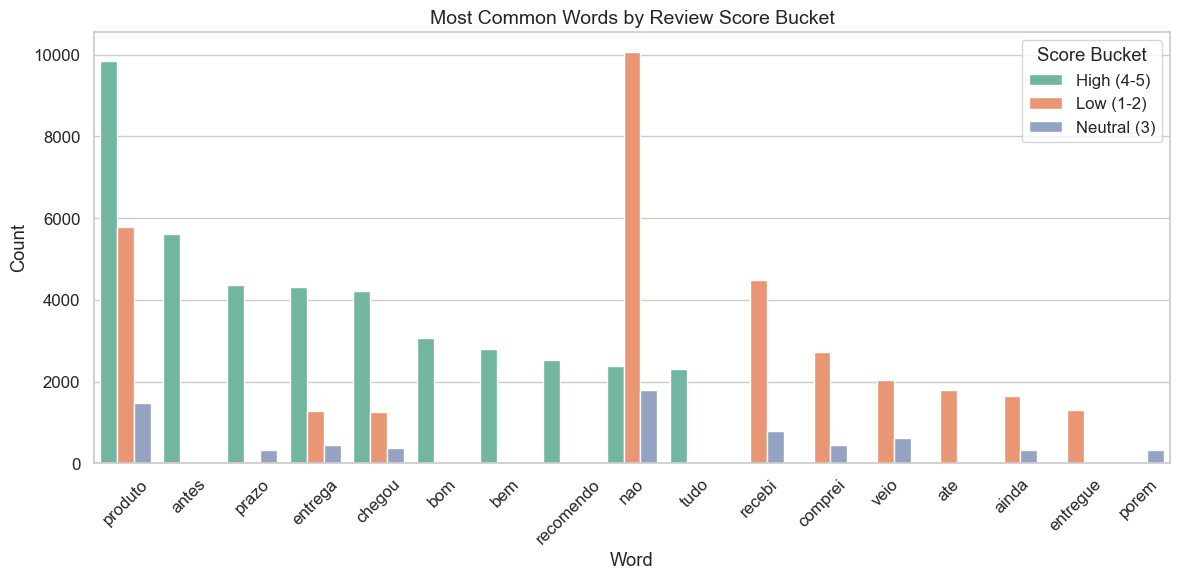

In [71]:
# Word Frequency by Review Score

from collections import Counter

df_reviews = orders_reviews.copy()

# Split scores into buckets
def bucket_score(score):
    if score <= 2:
        return "Low (1-2)"
    elif score == 3:
        return "Neutral (3)"
    else:
        return "High (4-5)"

df_reviews["score_bucket"] = df_reviews["review_score"].apply(bucket_score)

# Tokenize + clean
def tokenize(text):
    if pd.isnull(text):
        return []
    words = text.lower().split()
    words = [unidecode.unidecode(w) for w in words]        # remove accents
    words = [w for w in words if len(w) >= 3]              # min length = 3
    words = [w for w in words if w not in stopwords_pt]    # remove stopwords
    return words

df_reviews["tokens"] = df_reviews["review_comment_message"].apply(tokenize)

# Count most common words per bucket
top_words = {}
for bucket in df_reviews["score_bucket"].unique():
    all_tokens = [word for tokens in df_reviews[df_reviews["score_bucket"] == bucket]["tokens"] for word in tokens]
    counter = Counter(all_tokens)
    top_words[bucket] = counter.most_common(10)

# Convert to DataFrame for plotting
records = []
for bucket, words in top_words.items():
    for word, count in words:
        records.append({"bucket": bucket, "word": word, "count": count})

df_words = pd.DataFrame(records)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_words,
    x="word", y="count", hue="bucket", palette="Set2", dodge=True, legend=True
)
plt.title("Most Common Words by Review Score Bucket", fontsize=14)
plt.xlabel("Word")
plt.ylabel("Count")
plt.legend(title="Score Bucket")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [72]:
# TF-IDF (Term Frequency–Inverse Document Frequency) to identify words that are especially unique to low reviews

from sklearn.feature_extraction.text import TfidfVectorizer

low_reviews = df_reviews[df_reviews["review_score"].isin([1,2])]["review_clean"]

vectorizer = TfidfVectorizer(max_features=20)
X = vectorizer.fit_transform(low_reviews)

tfidf_words = sorted(zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0)), key=lambda x: x[1], reverse=True)

print("Top distinctive words in low reviews:")
for word, score in tfidf_words[:20]:
    print(f"{word}: {score:.2f}")

Top distinctive words in low reviews:
nao: 3258.18
produto: 2843.55
de: 2265.01
recebi: 1933.65
em: 1624.79
entregar: 1420.90
comprei: 1252.33
vir: 1177.13
chegar: 1014.80
ter: 926.67
ainda: 899.82
ate: 854.21
entrega: 769.29
dois: 735.26
compra: 629.71
dia: 612.82
apenas: 606.14
pedido: 578.30
loja: 557.85
outro: 529.87


In [73]:
# Checking bigrams (2 words together)

from sklearn.feature_extraction.text import CountVectorizer

# Create bigrams
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words=None, max_features=50)
X = vectorizer.fit_transform(low_reviews)

# Get top bigrams
bigram_freq = pd.DataFrame({
    'bigram': vectorizer.get_feature_names_out(),
    'count': X.sum(axis=0).A1
}).sort_values(by='count', ascending=False)

print("Top bigrams in low reviews:")
print(bigram_freq.head(20))

Top bigrams in low reviews:
              bigram  count
33        nao recebi   2297
47    recebi produto   1377
42       produto nao   1055
1          ainda nao   1038
30      nao entregar    983
11        de produto    964
34           nao ter    700
28        nao chegar    696
2          ate agora    671
5       comprei dois    479
36       nota fiscal    424
44       produto vir    413
4        ate momento    412
46     recebi apenas    392
19           em site    368
20    entrar contato    363
6    comprei produto    349
41  produto entregar    343
0          agora nao    306
10          de prazo    274


In [74]:
# Checking trigrams (three-word phrases)
vectorizer = CountVectorizer(ngram_range=(3,3), min_df=5, token_pattern=r'\b\w{3,}\b')
X_trigrams = vectorizer.fit_transform(low_reviews)
trigram_counts = X_trigrams.sum(axis=0)
trigram_freq = [(word, trigram_counts[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
trigram_freq = sorted(trigram_freq, key=lambda x: x[1], reverse=True)

# Top 20 trigrams
trigram_freq[:20]

[('nao recebi produto', 1096),
 ('ainda nao recebi', 522),
 ('produto nao entregar', 321),
 ('ate agora nao', 290),
 ('ate momento nao', 188),
 ('produto nao chegar', 178),
 ('produto ainda nao', 169),
 ('ainda nao chegar', 151),
 ('momento nao recebi', 128),
 ('ate agora nada', 123),
 ('ainda nao entregar', 119),
 ('agora nao recebi', 117),
 ('nao entregar produto', 109),
 ('comprei dois produto', 87),
 ('nao obtive resposta', 85),
 ('ate hoje nao', 77),
 ('querer dinheiro volta', 71),
 ('recebi produto nao', 71),
 ('nao recebi mercadoria', 70),
 ('dia ainda nao', 69)]

In [75]:
# Comparative Word Analysis (Low vs High Reviews)

high_reviews = df_reviews[df_reviews['review_score'] >= 4]["review_clean"].dropna()

# Vectorizer
tfidf = TfidfVectorizer(min_df=5, token_pattern=r'\b\w{3,}\b', stop_words=stopwords.words('portuguese'))

# Fit on all reviews
all_reviews = pd.concat([low_reviews, high_reviews])
tfidf.fit(all_reviews)

# Transform separately
low_tfidf = tfidf.transform(low_reviews)
high_tfidf = tfidf.transform(high_reviews)

# Average TF-IDF per word
low_mean = np.array(low_tfidf.mean(axis=0)).flatten()
high_mean = np.array(high_tfidf.mean(axis=0)).flatten()
feature_names = tfidf.get_feature_names_out()

# Top distinctive words for low reviews
distinctive_low = sorted(zip(feature_names, low_mean - high_mean), key=lambda x: x[1], reverse=True)[:20]
distinctive_low

[('nao', 0.09981435748045135),
 ('recebi', 0.055324803102200185),
 ('produto', 0.03869891403075127),
 ('comprei', 0.032714864863994185),
 ('ainda', 0.02690505699551407),
 ('vir', 0.022191460155708775),
 ('ate', 0.02164534223964094),
 ('dois', 0.0202180330935187),
 ('ter', 0.017880102838922107),
 ('apenas', 0.01608741202290288),
 ('entregar', 0.014253693814041724),
 ('dia', 0.01418381859331815),
 ('pedido', 0.013959104726527926),
 ('faltar', 0.013530177433748866),
 ('outro', 0.01266398094074704),
 ('agora', 0.012486695812573195),
 ('unidade', 0.012462661894815975),
 ('aguardar', 0.011863797141550426),
 ('pedir', 0.01030234188995192),
 ('receber', 0.00996243427601496)]

**Insight** – Low Reviews Analysis (Written Reviews, in Portuguese)

From the analysis of written reviews with low scores (≤2):

- Most common words in low reviews include "nao" (not), "recebi" (received), "produto" (product), "comprei" (bought), and "ainda" (still). This indicates that negative reviews often express issues with products not being received or delivered as expected.

- Frequent bigrams such as "nao recebi" (did not receive), "recebi produto" (received product), and "ainda nao recebi" (still did not receive) reinforce that delivery problems are the primary source of dissatisfaction.

- Top trigrams highlight specific complaints, including:
    - "nao recebi produto" (did not receive product)
    - "ainda nao recebi" (still did not receive)
    - "produto nao entregar" (product did not deliver)
    - "produto nao chegar" (product did not arrive)

These patterns show that customers often emphasize non-receipt of orders as the main pain point.

- Comparative word analysis against high reviews confirms that words like "nao", "recebi", "produto", and "comprei" are strongly associated with low reviews, while high reviews rarely use them in a negative context.

**Takeaway:** Negative sentiment is largely driven by delivery issues, particularly products not arriving or delays in receiving them. Companies can prioritize improving delivery reliability, tracking, and communication to reduce these low-score reviews.

# Orders and Sellers

In [76]:
# Count how many orders each seller handled
seller_order_counts = order_items.groupby('seller_id')['order_id'].nunique().reset_index()
seller_order_counts.rename(columns={'order_id': 'num_orders'}, inplace=True)

# Sort sellers by number of orders
seller_order_counts = seller_order_counts.sort_values(by='num_orders', ascending=False)

# Calculate cumulative share of orders
seller_order_counts['cum_orders'] = seller_order_counts['num_orders'].cumsum()
seller_order_counts['cum_share'] = seller_order_counts['cum_orders'] / seller_order_counts['num_orders'].sum()

# Show top 10 sellers
print(seller_order_counts.head(10))

# Example: % of orders handled by top 1%, 5%, 10% sellers
total_sellers = len(seller_order_counts)
for pct in [0.01, 0.05, 0.10]:
    cutoff = int(total_sellers * pct)
    share = seller_order_counts.iloc[:cutoff]['num_orders'].sum() / seller_order_counts['num_orders'].sum()
    print(f"Top {int(pct*100)}% sellers handle {share:.2%} of all orders.")

                             seller_id  num_orders  cum_orders  cum_share
1235  6560211a19b47992c3666cc44a7e94c0        1854        1854       0.02
881   4a3ca9315b744ce9f8e9374361493884        1806        3660       0.04
2481  cc419e0650a3c5ba77189a1882b7556a        1706        5366       0.05
368   1f50f920176fa81dab994f9023523100        1404        6770       0.07
2643  da8622b14eb17ae2831f4ac5b9dab84a        1314        8084       0.08
1824  955fee9216a65b617aa5c0531780ce60        1287        9371       0.09
1505  7a67c85e85bb2ce8582c35f2203ad736        1160       10531       0.11
2836  ea8482cd71df3c1969d7b9473ff13abc        1146       11677       0.12
857   4869f7a5dfa277a7dca6462dcf3b52b2        1132       12809       0.13
731   3d871de0142ce09b7081e2b9d1733cb1        1080       13889       0.14
Top 1% sellers handle 26.25% of all orders.
Top 5% sellers handle 53.45% of all orders.
Top 10% sellers handle 68.36% of all orders.


In [77]:
# Merge sellers with geolocation data
sellers_geo = sellers.merge(geolocation, 
                            left_on='seller_zip_code_prefix', 
                            right_on='geolocation_zip_code_prefix',
                            how='left')

# Checking seller distribution by state
seller_state_dist = sellers_geo['geolocation_state'].value_counts(normalize=True) * 100
print("Seller distribution by state (%):\n", seller_state_dist.head(10))

# Compare with customer state distribution
customer_state_dist = customers.merge(geolocation,
                                      left_on='customer_zip_code_prefix',
                                      right_on='geolocation_zip_code_prefix',
                                      how='left')['geolocation_state'].value_counts(normalize=True) * 100

print("\nCustomer vs Seller State distribution:")
print(pd.concat([customer_state_dist.head(10), seller_state_dist.head(10)], axis=1, keys=['Customers','Sellers']))

Seller distribution by state (%):
 geolocation_state
SP   53.55
MG   14.40
PR   10.67
RJ    8.36
SC    5.91
RS    4.14
ES    0.74
GO    0.66
BA    0.61
DF    0.30
Name: proportion, dtype: float64

Customer vs Seller State distribution:
                   Customers  Sellers
geolocation_state                    
SP                     37.26    53.55
RJ                     19.99     8.36
MG                     19.09    14.40
RS                      5.34     4.14
PR                      4.15    10.67
SC                      3.57     5.91
BA                      2.43     0.61
ES                      2.10     0.74
GO                      0.88     0.66
MT                      0.81      NaN
DF                       NaN     0.30


In [83]:
# Merging Sellers and Order_Items
sellers_orders = order_items[['order_id', 'seller_id']].merge(sellers, on='seller_id', how='left')

# Merging result with Order_Reviews, to have full dataframe with all possible information
df = orders_reviews.merge(sellers_orders, on=['order_id', 'seller_id'], how='left')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_status,has_comment,review_clean,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,housewares,40.00,268.00,4.00,500.00,19.00,8.00,13.00,a54f0611adc9ed256b57ede6b6eb5114,4.00,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,On-time,True,nao testar produto ainda vir correto bom Condi...,"9,350.00",maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,perfumery,29.00,178.00,1.00,400.00,19.00,13.00,19.00,8d5266042046a06655c8db133d120ba5,4.00,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,On-time,True,bom produto,"31,570.00",belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,auto,46.00,232.00,1.00,420.00,24.00,19.00,21.00,e73b67b67587f7644d5bd1a52deb1b01,5.00,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,On-time,False,,"14,840.00",guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,1.00,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00,359d03e676b3c069f62cadba8dd3f6e8,5.00,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,On-time,True,produto exatamente esperar descrito em o site ...,"31,842.00",belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,1.00,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,stationery,38.00,316.00,4.00,250.00,51.00,15.00,15.00,e50934924e227544ba8246aeb3770dd4,5.00,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,On-time,False,,"8,752.00",mogi das cruzes,SP


In [95]:
# Checking Seller Location vs. Delivery Delays

# Group by seller state
delivery_by_state = df.groupby(['seller_state','delivery_status']).size().unstack(fill_value=0)

# Add percentages
delivery_by_state['total'] = delivery_by_state.sum(axis=1)
for col in ['On-time','Late','Never Arrived']:
    delivery_by_state[col] = delivery_by_state[col] / delivery_by_state['total'] * 100

print(delivery_by_state[['On-time','Late','Never Arrived']].round(2).sort_values('Late',ascending=False))

delivery_status  On-time  Late  Never Arrived
seller_state                                 
AM                 33.33 66.67           0.00
MA                 73.97 25.34           0.68
PA                 87.50 12.50           0.00
RN                 87.88 12.12           0.00
SP                 89.69  8.19           2.12
MS                 91.84  8.16           0.00
CE                 88.89  8.08           3.03
DF                 91.01  7.75           1.25
RJ                 90.64  6.98           2.38
PR                 91.53  6.25           2.21
SC                 92.06  5.62           2.31
MT                 93.79  5.59           0.62
ES                 93.08  5.53           1.38
MG                 91.83  5.47           2.70
PB                 92.86  4.76           2.38
RS                 94.09  4.69           1.22
BA                 93.55  4.30           2.15
GO                 94.63  3.68           1.70
PE                 96.44  3.05           0.51
RO                100.00  0.00    

In [97]:
# Reviews of Top Sellers vs. Overall Average

avg_review_per_seller = df.groupby('seller_id')['review_score'].mean().reset_index()

# Rank sellers by order volume
seller_order_volume = df.groupby('seller_id')['order_id'].nunique().reset_index()
seller_order_volume.rename(columns={'order_id':'num_orders'}, inplace=True)

seller_stats = avg_review_per_seller.merge(seller_order_volume, on='seller_id')
seller_stats = seller_stats.sort_values(by='num_orders', ascending=False).reset_index(drop=True)

# Total average
overall_avg = seller_stats['review_score'].mean()

# Function to compute review avg for top X% sellers
def top_seller_avg(pct):
    cutoff = int(len(seller_stats) * pct)
    return seller_stats.iloc[:cutoff]['review_score'].mean()

print("Overall average review score:", round(overall_avg,2))
for pct in [0.01, 0.05, 0.10, 0.20]:
    print(f"Top {int(pct*100)}% sellers average review score: {round(top_seller_avg(pct),2)}")

Overall average review score: 3.94
Top 1% sellers average review score: 3.92
Top 5% sellers average review score: 3.97
Top 10% sellers average review score: 3.96
Top 20% sellers average review score: 4.02


In [102]:
# Checking Average review scores and delivery punctuality by seller (to identify top/bottom performers)

seller_summary = df.groupby('seller_id').agg(
    avg_review=('review_score','mean'),
    total_orders=('order_id','count'),
    pct_late=('delivery_status', lambda x: (x=='Late').mean()*100),
    pct_never=('delivery_status', lambda x: (x=='Never Arrived').mean()*100)
).reset_index()

# Top & bottom performers (by avg review & lateness)
top_sellers = seller_summary.sort_values('avg_review', ascending=False).head(50)
bottom_sellers = seller_summary.sort_values('avg_review', ascending=True).head(50)
print(top_sellers)
print(bottom_sellers)

                             seller_id  avg_review  total_orders  pct_late  \
2246  bbe87dce25ba8b38bb61cc7210a3f10b        5.00             2      0.00   
1057  5741dc2bf5044c34d0698681c5081bed        5.00             3      0.00   
2723  e439f7176d763f92de325271111b2fd5        5.00             7      0.00   
1015  53b0300ca793f9834cd69c0678d35ee8        5.00            24      0.00   
1023  544863df86ed3b78a04e0820d41430ee        5.00             1      0.00   
1035  5587130f9850696ed7fafbc91c2cee44        5.00             2      0.00   
2702  e1c76f339ebd5460999f25a2aa8c92c5        5.00             1      0.00   
338   1d0646a72178a6fb37ee8082140e06ec        5.00             2      0.00   
2701  e1bed63d68ac36fe1f3061befe196af5        5.00             1      0.00   
336   1cd9e0cc1839d55516843def5600816d        5.00             5      0.00   
335   1cbdc7cf130a41fd13a3c2a7d2fcfda7        5.00             2      0.00   
1054  570d4583587a5fe2d47c7be89b91ad27        5.00             2

In [106]:
# Checking generalist sellers (many SKUs) vs specialized sellers (few SKUs)

# Count unique products per seller
seller_products = df.groupby('seller_id')['product_id'].nunique().reset_index()
seller_products.rename(columns={'product_id':'unique_products'}, inplace=True)

# Merge with performance
catalog_perf = seller_summary.merge(seller_products, on='seller_id', how='left')

# Relationship between catalog size and sales/reviews
catalog_perf['sales'] = catalog_perf['total_orders']

# Correlation check
corr_results = catalog_perf[['unique_products','sales','avg_review']].corr()

# Example: group into buckets
catalog_perf['catalog_size'] = pd.cut(
                                      catalog_perf['unique_products'],
                                      bins=[0,5,20,100,1000],
                                      labels=['Very Few','Small','Medium','Large']
                                       )

catalog_stats = catalog_perf.groupby('catalog_size', observed=False).agg(
                                                         avg_sales=('sales','mean'),
                                                         avg_review=('avg_review','mean'),
                                                         sellers=('seller_id','count'),
                                                          ).reset_index()
print(catalog_stats)

  catalog_size  avg_sales  avg_review  sellers
0     Very Few       8.21        3.88     1846
1        Small      46.15        4.04      829
2       Medium     174.90        4.01      348
3        Large     871.29        3.95       45


**Insight Note** – Seller Insights

- The seller analysis highlights four key findings:
    - Geographic impact: Delivery reliability varies by state. Remote regions (e.g., AM, MA) show high late rates, while Southern/Southeastern sellers (e.g., RS, SC, SP) achieve better punctuality.
    - Market concentration: A small group dominates sales — the top 10% of sellers handle nearly 70% of all orders.
    - Customer experience drivers: High sales or broad catalogs do not guarantee better reviews. Instead, low-scoring sellers consistently show more late or failed deliveries, linking logistics directly to customer dissatisfaction.
    - Catalog breadth: Larger catalogs bring higher sales volume but no clear advantage in ratings.

*Implications:* Improving logistics reliability, especially in remote states, could raise customer satisfaction more effectively than growing catalog size or seller volume. Supporting smaller sellers with operational tools and delivery partnerships may help balance market concentration and improve overall marketplace performance.

# 📊 Final Summary — Olist EDA

This notebook presents an exploratory analysis of the Olist e-commerce dataset.  
Below are the most important findings and their business implications.

---

## 1. Deliveries & Customer Experience
- **On-time deliveries (~89.7%)** → average review **4.21**.  
- **Late deliveries (~7.6%)** → average review **2.55**.  
- **Never arrived (~2.7%)** → average review **1.76**.  
**Takeaway:** delivery punctuality is the single strongest driver of customer satisfaction.

---

## 2. Customers & Sellers Geography
- Customers concentrated in **SP, RJ, MG**; sellers are even more concentrated in **SP**.  
- Some states (e.g., **AM, MA**) show much higher late rates, indicating **regional logistics challenges**.

---

## 3. Seller Dynamics
- **High concentration:** top **1%** sellers handle **~26%** of orders; top **10%** handle **~68%**.  
- **Top sellers ≠ better reviews:** average ratings for top sellers are similar to the marketplace average (~3.9–4.0).  
- **Seller reliability matters:** low-scoring sellers are much more likely to have late or never-arrived orders.

---

## 4. Product & Presentation Insights
- Product presentation (description length, number of photos) has **no meaningful correlation** with units sold — most products have 1–3 photos.  
- Freight-to-price ratio varies by category and affects average order value; furniture-related categories show high freight ratios.

---

## 5. Reviews (Text Analysis)
- Negative reviews concentrate on **delivery and fulfilment**: top bigrams/trigrams include **"nao recebi", "ainda nao recebi", "nao recebi produto"** (didn't receive / still haven't received).  
- TF-IDF and phrase analysis confirm the main pain points: **delays, missing items, wrong quantities, invoice issues, and difficulty contacting support**.  
**Takeaway:** voice-of-the-customer analysis points to logistics & order accuracy as priority fixes.

---

## 6. Time Trends
- Orders show a massive single-day spike on **2017-11-24 (Black Friday)** — the highest daily volume in the dataset.
- Use event-aware capacity planning for marketing/logistics.

---

## Key Insights

- **Delivery performance is the single biggest factor affecting customer satisfaction.**
- **Geography matters:** sellers outside main hubs face logistics disadvantages.
- **Seller concentration is high**, but being a top seller does not guarantee better customer experience.
- **Retail events (e.g., Black Friday)** create huge demand peaks — important for capacity planning.

## Overall Recommendations (actionable)
1. **Prioritize logistics**: reduce late and failed deliveries (regional hubs, partners).  
2. **Improve tracking & proactive communication** for delayed shipments.  
3. **Monitor seller-level KPIs** (on-time rate, never-arrived rate) and support low-performers with operational playbooks.  
4. **Use event planning** (Black Friday) to scale capacity temporarily.  
5. **Include voice-of-customer monitoring** (automated keyword alerts for “nao recebi” / “produto errado”) to prioritize fixes.

---

## Files & Next Steps
- Notebook: `notebooks/EcommercePerformanceEDA.ipynb` (this document).  
- Data (not tracked on public repo unless permitted): `https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce`  
- Next step: build an interactive Power BI dashboard showing delivery KPIs, seller performance, and review drivers.

---
